# 1. 3.0 Efeito dos Parâmetros no Descarte de Bovinos na Pecuária de Corte V 3.0

# 2. Objetivo Geral

Uma fazenda bovina inteligente integra diversas fontes de dados (sensores IoT, APIs de clima, aplicativos de gestão) para alimentar algoritmos de Inteligência Artificial capazes de identificar precocemente quais animais estão prontos para o abate e quais apresentam baixo desempenho, aumentando a eficiência e a rentabilidade do negócio. Esses dados (peso, leite, clima, etc.) são coletados automaticamente no campo e enviados para uma plataforma central na nuvem. Em seguida, uma equipe de dados realiza o processamento (limpeza, organização e análise) e treinamento de modelos de IA.

# 3. Questão de Pesquisa

Maximizar a produtividade de uma propriedade rural requer monitorar indicadores de desempenho zootécnico e indicadores econômicos. Em sistemas de confinamento de engorda (pecuária de corte), cujo objetico primordial é engordar os animais até atingir o peso de 450 kg no menor tempo possivel e gastando o menos possível dos recursos da propriedade rural.

Monitorar indicadores zootécnicos permite avaliar a eficiência produtiva do rebanho e identificar pontos de melhoria no manejo e na nutrição dos animais. Sabendo o momento correto de **descartar** animais do rebanho com baixo desempenho operacional reduz os gastos com animais improdutivos. Alguns destes indicadores são:

* **Ganho Médio Diário (GMD_medio)** – Indica quantos quilos, em média, cada animal ganha por dia no confinamento. É um dos índices mais acompanhados, pois reflete se os animais estão performando conforme o esperado e respondendo bem à dieta. Um GMD elevado significa crescimento mais rápido, reduz o tempo de engorda e aumenta a produção de carne por período. Esse indicador orienta ajustes na alimentação: por exemplo, se o GMD estiver abaixo da meta, pode ser necessário reformular a dieta ou verificar problemas de saúde.
* **Índice de Conversão Alimentar (ICA)** – Mede a eficiência com que os animais convertem alimento em peso corporal. É calculado dividindo-se o consumo de ração pelo ganho de peso no período. Em confinamento, onde a alimentação é o maior custo, um ICA baixo (ou seja, poucos quilos de ração por quilo de ganho) indica alta eficiência alimentar. Melhorar a conversão alimentar – por exemplo, via balanceamento de dieta ou genética – impacta diretamente o custo por kg produzido.

* **Peso Final** - Indicador direto de desempenho absoluto. Baixo peso final pode indicar improdutividade.

* **z_score** - Avalia quão fora da média o animal está (comparado ao lote todo). Valores muito negativos sugerem baixo desempenho.

* **Dietas e Conversão Alimentar** - Custo e capacidade das dietas em ajudar os animais a converterem a alimentação oferecida em peso corporal.

* **Custo Total** - Reflete o custo absoluto de alimentar o animal no período. Deve ser sustentável.

O objetivo dessa pesquisa é, a partir de dataset gerado para um rebanho durante um período de confinamento, identificar aqueles animais com baixo desempenho e sinalizar o produtor rural, contribuindo desta forma diretamente para uma maior produtividade da propriedade rural.

Como não encontrei um dataset específico para pecuária de precisão, a primeira fase deste trabalho foi gerar um dataset para aplicar os métodos estatísticos de análise de dados e testes. Fiz uma pesquisa específica sobre as principais regras de negócio do confinamento de animais em fazendas de corte para gerar os dados para 200 animais durante o período de 60 adias. Procurei faze-lo parametrizado para faze-lo abrangente para vários tamanhos de propriedade rural. Obviamente muitas outras variáveis podem ser acrescentras.

Pretendo disponibilizar este dataset para outros pesquisadores. Em paralelo estou desenvolvendo ferramentas (falta a palavra certa) para coleta de dados em tempo real  em fazendas e gerar uma base de dados mais consistente e confiável.


# 4. Processo Experimental

In [ ]:
#===============================================================================
#           Bibliotecas Utilizadas
#===============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix
from scipy.stats import ttest_ind
from scipy.stats import levene
from sklearn.tree import plot_tree
from scipy.stats import f_oneway, mannwhitneyu, shapiro, kruskal
from scipy.stats import pearsonr, spearmanr, zscore

# 4.1 Geração do Dataset Animal

Descricao do dataset gerado

     AnimalID Dieta  PesoInicial   PesoFinal  GMD_medio       ICA  \
0           1     C   324.230170  396.798933   1.229979  8.679969   
1           2     A   303.893535  360.429463   0.958236  6.439939   
2           3     C   315.234925  372.183990   0.965238  8.352651   
3           4     C   314.812564  377.680411   1.065557  7.891231   
4           5     A   341.778256  405.123544   1.073649  6.112689   
..        ...   ...          ...         ...        ...       ...   
195       196     B   320.512780  367.481348   0.796077  7.260020   
196       197     C   305.507944  377.770809   1.224794  8.694509   
197       198     C   305.649419  361.433683   0.945496  8.607808   
198       199     B   318.684799  374.214599   0.941183  7.479970   
199       200     A   358.770632  419.352134   1.026805  6.918359   

     ConsumoTotalMS  CustoTotal  CustoPorKgGanho      Receita  MargemBruta  
0        629.894609  629.894609         8.679969  3967.989329  3338.094720  
1        364.0879

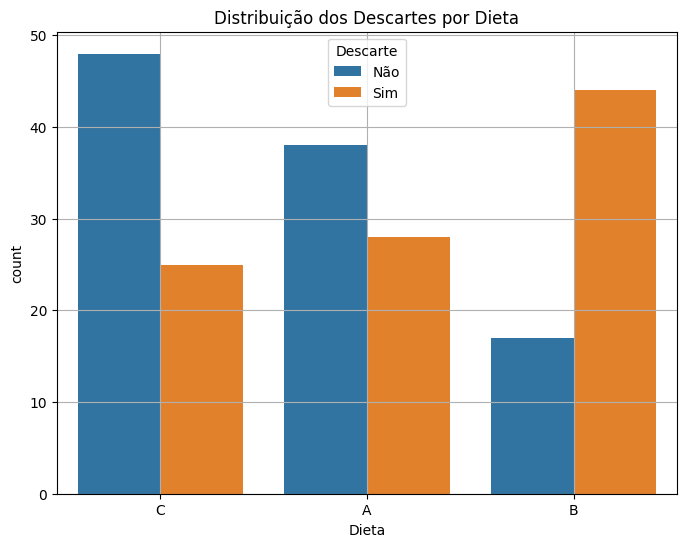

     AnimalID Dieta  PesoInicial   PesoFinal  GMD_medio  Limiar_GMD   z_score  \
0           1     C   324.230170  396.798933   1.229979    0.964092  1.287324   
1           2     A   303.893535  360.429463   0.958236    0.863250 -0.118343   
2           3     C   315.234925  372.183990   0.965238    0.964092 -0.082121   
3           4     C   314.812564  377.680411   1.065557    0.964092  0.436803   
4           5     A   341.778256  405.123544   1.073649    0.863250  0.478663   
..        ...   ...          ...         ...        ...         ...       ...   
195       196     B   320.512780  367.481348   0.796077    0.653858 -0.957154   
196       197     C   305.507944  377.770809   1.224794    0.964092  1.260504   
197       198     C   305.649419  361.433683   0.945496    0.964092 -0.184244   
198       199     B   318.684799  374.214599   0.941183    0.653858 -0.206554   
199       200     A   358.770632  419.352134   1.026805    0.863250  0.236350   

          ICA Descarte  
0 

In [ ]:
# ===============================
#     Simular dados
# ===============================
np.random.seed(42)

num_animais = 200
dias = 60
desvio_gmd = 0.15
desvio_ica = 0.3
desvio_ganho_dia = 0.2
limite_perda_dia = -0.3
ica_minimo = 5.5
peso_descarte = 380
idade_inicial_meses =18

animais = np.arange(1, num_animais + 1)

# ✅ Atribuir dietas aos animais
dietas = np.random.choice(['A', 'B', 'C'], size=num_animais)
dieta_animais = pd.DataFrame({
    'AnimalID': animais,
    'Dieta': dietas
})

# ✅ Definir parâmetros de ganho médio diário por dieta
ganho_base = {'A': 1.0, 'B': 0.8, 'C': 1.1}
ica_base = {'A': 6.5, 'B': 7.5, 'C': 8.5}

# ===============================
#  Gerar registros diários
# ===============================
registros = []
peso_inicial = np.random.uniform(300, 360, size=num_animais)

for idx, animal in enumerate(animais):
    peso = peso_inicial[idx]
    dieta = dieta_animais.loc[dieta_animais['AnimalID'] == animal, 'Dieta'].values[0]

    gmd_individual = max(np.random.normal(ganho_base[dieta], desvio_gmd), 0)
    ica_individual = max(np.random.normal(ica_base[dieta], desvio_ica), ica_minimo)

    for dia in range(1, dias + 1):
        if dia > 1:
            ganho_dia = max(np.random.normal(gmd_individual, desvio_ganho_dia), limite_perda_dia)
            peso += ganho_dia
        registros.append([
            animal, dia, peso, dieta, gmd_individual, ica_individual
        ])

# ===============================
#  Criar dataframe diário
# ===============================
df = pd.DataFrame(registros, columns=[
    'AnimalID', 'Dia', 'Peso', 'Dieta', 'GMD_individual', 'ICA'
])

# ===============================
#  Agregar dados por animal
# ===============================
peso_final = df.groupby('AnimalID')['Peso'].last()
peso_ini = df.groupby('AnimalID')['Peso'].first()

gmd_medio = (peso_final - peso_ini) / (dias - 1)

# Cálculo do z-score global
media_gmd = gmd_medio.mean()
dp_gmd = gmd_medio.std()

z_score = (gmd_medio - media_gmd) / dp_gmd

# ICA individual (fixo na simulação)
ica_individual = df.groupby('AnimalID')['ICA'].mean()

# ===============================
#  Construir o Dataset
# ===============================
df = pd.DataFrame({
    'AnimalID': animais,
    'Dieta': dietas,
    'PesoInicial': peso_ini.values,
    'PesoFinal': peso_final.values,
    'GMD_medio': gmd_medio.values,
    'z_score': z_score.values,
    'ICA': ica_individual.values
})

# Add 'idade_inicial_meses' and 'Sexo' columns
# df['idade_inicial_meses'] = idade_inicial_meses
# df['Sexo'] = np.random.choice(['0', '1'], size=num_animais)

# ===============================
#  Calcular média e DP por dieta
# ===============================
estatisticas_dieta = df.groupby('Dieta')['GMD_medio'].agg(['mean', 'std']).reset_index()
estatisticas_dieta.rename(columns={'mean': 'Media_GMD_Dieta', 'std': 'DP_GMD_Dieta'}, inplace=True)

# Merge com o dataframe dos animais
df = df.merge(estatisticas_dieta, on='Dieta', how='left')

# Definir limiar dinâmico de GMD
df['Limiar_GMD'] = df['Media_GMD_Dieta'] - df['DP_GMD_Dieta']

# =================================
#  Definir custo da dieta por tipo
# =================================
custo_dieta = {'A': 1.60, 'B': 1.30, 'C': 1.00}  # custo por kg de matéria seca (exemplo)

# ===============================
#  Adicionar custo da dieta no dataframe dos animais
# ===============================
df['CustoDieta'] = df['Dieta'].map(custo_dieta)

# ============================================
#  Calcular Consumo Total de Matéria Seca (MS)
# ============================================
df['ConsumoTotalMS'] = df['ICA'] * (df['PesoFinal'] - df['PesoInicial'])

# ===============================
# 3. Condições ambientais
# ===============================
temp_dia = {dia: np.random.uniform(15, 35) for dia in range(1, dias + 1)}
umid_dia = {dia: np.random.uniform(50, 90) for dia in range(1, dias + 1)}

# ===============================
#  Calcular Custo Total de Alimentação
# ===============================
df['CustoTotal'] = df['ConsumoTotalMS'] * df['CustoDieta']

# ===============================
#  Custo por kg de peso ganho
# ===============================
#  Fórmula: CustoPorKgGanho = CustoTotal / (PesoFinal - PesoInicial)
df['CustoPorKgGanho'] = df['CustoTotal'] / (df['PesoFinal'] - df['PesoInicial'])

# ===============================
# (Opcional) Calcular Receita e Margem Bruta
# ===============================
#  Exemplo: preço de venda por kg = R$ 10,00
preco_por_kg = 10.00

# Receita do animal (PesoFinal × preço)
df['Receita'] = df['PesoFinal'] * preco_por_kg

#  Margem Bruta = Receita - CustoTotal
df['MargemBruta'] = df['Receita'] - df['CustoTotal']

# ===============================
# ☥️ Verificar resultado
# ===============================
print(df[['AnimalID', 'Dieta', 'PesoInicial', 'PesoFinal', 'GMD_medio',
          'ICA', 'ConsumoTotalMS', 'CustoTotal', 'CustoPorKgGanho',
          'Receita', 'MargemBruta']])

# ===============================
#  Critérios de Descarte
# ===============================
df['Descarte'] = np.where(
    (df['PesoFinal'] < peso_descarte) |
    (df['GMD_medio'] < df['Limiar_GMD']) |
    (df['ICA'] > 9.0) |
    (df['z_score'] < -1),
    'Sim', 'Não'
)

# # Criando a coluna "Classificacao" com base nas regras fornecidas

# def classificar_bovino(row):
#     idade = row["idade_inicial_meses"]
#     sexo = row["Sexo"].strip().capitalize()  # Normaliza possíveis inconsistãncias de entrada

#     if idade <= 12:
#         return "1"
#     elif idade <= 24:
#         return "2"
#     elif idade > 24:
#         if sexo == "0":
#             return "3"
#         elif sexo == "1":
#             return "4"

#     return "4"  # Caso nenhuma condição anterior tenha sido atendida e o sexo esteja inconsistente


# df["Classificacao"] = df.apply(classificar_bovino, axis=1)


# ===============================
#  Visualizações
# ===============================
plt.figure(figsize=(8,6))
sns.countplot(data=df, x='Dieta', hue='Descarte')
plt.title('Distribuição dos Descartes por Dieta')
plt.grid(True)
plt.show()

# ===============================
# ☥️ Verificar tabela final
# ===============================
print(df[['AnimalID', 'Dieta', 'PesoInicial', 'PesoFinal', 'GMD_medio',
                  'Limiar_GMD', 'z_score', 'ICA','Descarte']])


In [ ]:
df

,AnimalID,Dieta,PesoInicial,PesoFinal,GMD_medio,z_score,ICA,idade_inicial_meses,Sexo,Media_GMD_Dieta,DP_GMD_Dieta,Limiar_GMD,CustoDieta,ConsumoTotalMS,CustoTotal,CustoPorKgGanho,Receita,MargemBruta,Descarte,Classificacao
0,1,C,324.230170,396.798933,1.229979,1.287324,8.679969,18,0,1.115901,0.151809,0.964092,1.0,629.894609,629.894609,8.679969,3967.989329,3338.094720,Não,2
1,2,A,303.893535,360.429463,0.958236,-0.118343,6.439939,18,1,0.997037,0.133787,0.863250,1.6,364.087901,582.540642,10.303902,3604.294628,3021.753986,Sim,2
2,3,C,315.234925,372.183990,0.965238,-0.082121,8.352651,18,0,1.115901,0.151809,0.964092,1.0,475.675663,475.675663,8.352651,3721.839900,3246.164237,Sim,2
3,4,C,314.812564,377.680411,1.065557,0.436803,7.891231,18,1,1.115901,0.151809,0.964092,1.0,496.104692,496.104692,7.891231,3776.804114,3280.699422,Sim,2
4,5,A,341.778256,405.123544,1.073649,0.478663,6.112689,18,1,0.997037,0.133787,0.863250,1.6,387.210054,619.536086,9.780303,4051.235440,3431.699353,Não,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,196,B,320.512780,367.481348,0.796077,-0.957154,7.260020,18,1,0.802584,0.148726,0.653858,1.3,340.992762,443.290591,9.438027,3674.813478,3231.522887,Sim,2
196,197,C,305.507944,377.770809,1.224794,1.260504,8.694509,18,1,1.115901,0.151809,0.964092,1.0,628.290102,628.290102,8.694509,3777.708095,3149.417993,Sim,2
197,198,C,305.649419,361.433683,0.945496,-0.184244,8.607808,18,1,1.115901,0.151809,0.964092,1.0,480.180237,480.180237,8.607808,3614.336834,3134.156596,Sim,2
198,199,B,318.684799,374.214599,0.941183,-0.206554,7.479970,18,0,0.802584,0.148726,0.653858,1.3,415.361253,539.969629,9.723961,3742.145989,3202.176360,Sim,2


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   AnimalID         200 non-null    int64  
 1   Dieta            200 non-null    object 
 2   PesoInicial      200 non-null    float64
 3   PesoFinal        200 non-null    float64
 4   GMD_medio        200 non-null    float64
 5   z_score          200 non-null    float64
 6   ICA              200 non-null    float64
 7   Media_GMD_Dieta  200 non-null    float64
 8   DP_GMD_Dieta     200 non-null    float64
 9   Limiar_GMD       200 non-null    float64
 10  CustoDieta       200 non-null    float64
 11  ConsumoTotalMS   200 non-null    float64
 12  CustoTotal       200 non-null    float64
 13  CustoPorKgGanho  200 non-null    float64
 14  Receita          200 non-null    float64
 15  MargemBruta      200 non-null    float64
 16  Descarte         200 non-null    object 
dtypes: float64(14), 

# 4.2 Dicionário dos Dados e Variáveis
| Coluna                     | Descrição                                                                 |
|---------------------------|---------------------------------------------------------------------------|
| `Animal ID`               | Identificação unica do Animal (RFID)
| `PesoInicial`          | Peso do animal no início do ciclo        |
 `PesoFinal`          | Peso no final do ciclo         |
| `GMD_medio` | Ganho de peso diário        |
| `z_score`             | Desempenho relativo dentro da população                 |
| `ICA`          | Índice de Conversão Alimentar              |
| `CustoDieta` |Custo da dieta associada                |
| `ConsumoTotalMS`           | Consumo total de matéria seca              |
| `CustoTotal`  | Custo total de alimentação no ciclo                  |
| `Media_GMD_Dieta`          | Desvio padrão de Média de GMD da dieta do animal        |
| `Limiar_GMD` | Limiar mínimo aceitável de GMD (Média - DP)    
| `MargemBruta`             |Receita - Custo Dieta            
| `Descarte`             | Variável-alvo em modelos de classificação para descarte de animal                 |

In [ ]:
# Como indicativo para outros testes, define-se as colunas categóricas, numéricas (Variáveis de análise obrigratórias) e de interesse

categorical_columns = ["Descarte"]
numerical_columns = ["PesoFinal", "PesoInicial","GMD_medio","z_score","ICA","CustoTotal","CustoPorKgGanho","Limiar_GMD","MargemBruta", "ConsumoTotalMS", "CustoDieta","Receita"]

variaveis_de_interesse = ['PesoInicial', 'PesoFinal', 'GMD_medio','ICA','ConsumoTotalMS',
                           'CustoDieta','CustoPorKgGanho','CustoTotal','z_score', 'Receita','MargemBruta']

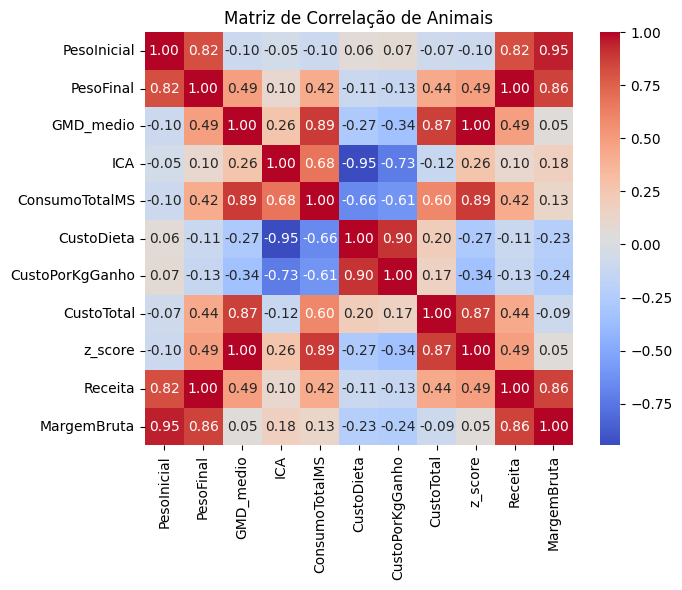

In [ ]:
# ===============================================================================
#     A Matriz de Correlação
# ==============================================================================

#df_numerico = df.select_dtypes(include='number')
#correlacao = df_numerico.corr()
corr = df[variaveis_de_interesse].corr()

plt.figure(figsize=(7,6))  # Define o tamanho do gráfico
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlação de Animais')
plt.tight_layout()
plt.show()

<table>
  <tr>
    <th>Variável</th>
    <th>Correlação Importante</th>
    <th>Interpretaçã Prática</th>
  </tr>
  <tr>
    <td>GMD_medio x ConsumoTotalMS</td>
    <td>+0.89 </td>
    <td>Forte correlação positiva, Animais que ganham mais peso consomem mais matéria seca</td>
</td>
  <tr>
    <td>GMD_medio x CustoTotal</td>
    <td>+0.87</td>
    <td>Quanto maior o GMD_medio, maior o custo total de alimentação — coerente, já que o consumo aumenta</td>
  </tr>
  <tr>
    <td>GMD_medio x z_score</td>
    <td>+1.00</td>
    <td>Esperado, pois o z_score foi derivado diretamente do GMD.</td>
  </tr>
  <tr>
    <td>ICA X CustoPorKgGanho </td>
    <td>-0.73</td>
    <td> Altamente correlacionado: quanto pior a conversão (maior ICA), mais caro fica cada kg ganho.</td>
  </tr>
  <tr>
    <td>ICA x CustoTotal</td>
    <td>+0.44</td>
    <td>Conversão ineficiente tende a gerar custos mais altos.</td>
  </tr>
  <tr>
    <td>CustoPorKgGanho x ICA </td>
    <td>-0.73</td>
    <td> Altamente correlacionado: quanto pior a conversão (maior ICA), mais caro fica cada kg ganho</td>
  </tr>
  <tr>
    <td> CustoPorKgGanho x CustoDieta  </td>
    <td>+0.90</td>
    <td>Dietas mais caras tornam o custo por kg ganho muito mais elevado.</td>
  </tr>
  <tr>
    <td>CustoPorKgGanho x ConsumoTotalMS</td>
    <td>-0.61</td>
    <td>nversamente proporcional: quem consome mais (com boa eficiência) tende a reduzir o custo por kg.</td>
  </tr>
  <tr>
    <td>PesoInicial x PesoFinal</td>
    <td>+0.82</td>
    <td>Forte correlação, como esperado.</td>
  </tr>
    <td>PesoInicial x Receita</td>
    <td>+0.82</td>
    <td>Animais mais pesados geram maior receita final</td>
  </tr>
    <td>PesoInicial x MargemBruta</td>
    <td>+0.95</td>
    <td>Altamente correlacionado: peso inicial é um dos principais determinantes da margem.\</td>
  </tr>
    <td>CustoDieta x ICA</td>
    <td>-0.95</td>
    <td>Fortemente negativa: dietas mais baratas (como a C) têm ICA mais elevado, indicando conversão pior.</td>
  </tr>
    <td>CustoDieta x CustoPorKgGanho</td>
    <td>+0.90</td>
    <td>Quanto mais cara a dieta, maior o custo por kg de ganho.</td>
  </tr>
    <td>CustoDieta xConsumoTotalMS</td>
    <td>-0.66</td>
    <td>Dietas mais caras estão associadas a menores consumos totais, talvez pela relação inversa com ICA.\</td>
  </tr>
    <td>Receita x PesoFinal</td>
    <td>+1.00</td>
    <td>Receita é diretamente proporcional ao peso final do animal (receita = peso × preço).</td>
  </tr>
    <td>Receita x MargemBruta</td>
    <td>+0.86</td>
    <td>Mais receita geralmente significa margem maior, desde que os custos não superem esse ganho.\</td>
  </tr>
    <td>MargemBruta x PesoInicial</td>
    <td>+0.95</td>
    <td>Quanto mais gordo o animal maior a margem de lucro</td>
  </tr>
    <td>MargemBruta x Receita</td>
    <td>+0.86</td>
    <td>Receita é diretamente proporcional ao peso final do animal (receita = peso × preço).</td>
  </tr>
    <td>MargemBruta x CustoTotalk</td>
    <td>-0.09</td>
    <td>A margem está mais ligada à receita (peso final) do que ao custo direto.\</td>
</table>


**Interpretaçãdas principais correlações**
*   GMD_medio vs PesoFinal (**r ≈ 0.49**):Animais com maior GMD tendem a ter maior peso final — esperado e desejável.
*   GMD_medio vs ICA (**r ≈ 0.26**):Animais com maior GMD geralmente consomem mais — mas como a correlação é fraca, há variabilidade na eficiência.
*   GMD_medio vs CustoPorKgGanho (**r ≈ -0.34**): Quanto maior o GMD, menor o custo por kg de peso ganho — ou seja, melhor desempenho → mais eficiência econômica.
*   ICA vs CustoPorKgGanho (**r ≈ 0.90**): Índice de conversão alimentar alto (menos eficiente) leva a custo mais alto por kg ganho — esperado e crítico para decisões.
*   PesoFinal vs Receita (**r ≈ 1.00**): A receita depende diretamente do peso final (preço × peso), como esperado.
*   CustoTotal vs Receita (**r ≈ 0.86**): Quem ganha mais peso consome mais e gera mais custo — mas isso também aumenta a receita.
*   CustoDieta vs ICA (**r ≈ -0.95**): Dietas mais caras (como a A) tendem a ter animais mais eficientes (menor ICA) — possível reflexo de melhor qualidade nutricional.
*   CustoDieta vs CustoPorKgGanho (**r ≈ -0.73**): Apesar de mais cara, a dieta pode compensar pelo melhor desempenho, reduzindo o custo por kg ganho.
*   MargemBruta vs CustoTotal (**r ≈ -0.24**): A margem depende não só do custo, mas principalmente da relação entre receita e eficiência.
*   GMD_medio vs z_score (**r ≈ 1.00**): O z-score foi derivado do GMD, então a correlação é perfeita.

**Conclusões Práticas**

*   **GMD é o indicador central de desempenho zootécnico.**
*   **ICA e CustoPorKgGanho** são cruciais para avaliar a eficiência alimentar.
*   **Dietas** mais caras parecem promover melhor desempenho e eficiência, o que compensa o custo.
*   A **receita** aumenta com o peso final, mas não necessariamente com eficiência econômica.
*   **Descarte** (variável alvo) de animais deve considerar GMD, ICA e eficiência econômica (CustoPorKgGanho e MargemBruta), não apenas peso.



In [ ]:
#===============================================================================
#       O Dataframe de Animais
#===============================================================================
df

,AnimalID,Dieta,PesoInicial,PesoFinal,GMD_medio,z_score,ICA,Media_GMD_Dieta,DP_GMD_Dieta,Limiar_GMD,CustoDieta,ConsumoTotalMS,CustoTotal,CustoPorKgGanho,Receita,MargemBruta,Descarte
0,1,C,324.230170,396.798933,1.229979,1.287324,8.679969,1.115901,0.151809,0.964092,1.0,629.894609,629.894609,8.679969,3967.989329,3338.094720,Não
1,2,A,303.893535,360.429463,0.958236,-0.118343,6.439939,0.997037,0.133787,0.863250,1.6,364.087901,582.540642,10.303902,3604.294628,3021.753986,Sim
2,3,C,315.234925,372.183990,0.965238,-0.082121,8.352651,1.115901,0.151809,0.964092,1.0,475.675663,475.675663,8.352651,3721.839900,3246.164237,Sim
3,4,C,314.812564,377.680411,1.065557,0.436803,7.891231,1.115901,0.151809,0.964092,1.0,496.104692,496.104692,7.891231,3776.804114,3280.699422,Sim
4,5,A,341.778256,405.123544,1.073649,0.478663,6.112689,0.997037,0.133787,0.863250,1.6,387.210054,619.536086,9.780303,4051.235440,3431.699353,Não
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,196,B,320.512780,367.481348,0.796077,-0.957154,7.260020,0.802584,0.148726,0.653858,1.3,340.992762,443.290591,9.438027,3674.813478,3231.522887,Sim
196,197,C,305.507944,377.770809,1.224794,1.260504,8.694509,1.115901,0.151809,0.964092,1.0,628.290102,628.290102,8.694509,3777.708095,3149.417993,Sim
197,198,C,305.649419,361.433683,0.945496,-0.184244,8.607808,1.115901,0.151809,0.964092,1.0,480.180237,480.180237,8.607808,3614.336834,3134.156596,Sim
198,199,B,318.684799,374.214599,0.941183,-0.206554,7.479970,0.802584,0.148726,0.653858,1.3,415.361253,539.969629,9.723961,3742.145989,3202.176360,Sim


# 5. Delineamento de Experimentos (DOE)



**Passo 1 - Objetivo**: *Avaliar o efeito das **dietas (A, B, C)** sobre o **Ganho Médio de Peso Diário (GMD_medio), Indice de Conversão Alimentar (ICA) e Custo Por Quilo  Ganho (CustoPorKgGanho)**.* - conforme indicado pela matriz de correlação

**Passo 2 - Fator**: Tipo de Dieta A, B ou C

**Passo 3 - Variáveis de Resposta**: GMD_medio, ICA, CustoPorKgGanho

**Passo 4 - Tipo de DOE**: Delineamente Inteiramente Casualizado (DIC)

**Passo 5 - Simular Dataset**: Simular os dados para 30 dias.

**Passo 6 - Executar os testes para definir a viabilidade do teste ANOVA**

1.   Independencia das observações: os animais estão em piquetes diferentes ✅
2.   Normalidade dos Resíduos: Teste de Shapiro-Wilk: requisito para o ANOVA ✅
3.   Homogeneidade de variâncias (Levene): requisito para o ANOVA ✅
4.   Análise de Variância (ANOVA) → Verificar se as dietas afetam GMD, ICA, Custo.

**Commentarios**


*   Todas as dietas estão com o p-value >  0.05, distribuição normal
*   Nos três grupos de dietas (A,B,C) as variâncias do GMD são semelhantes
*   Como as três condições foram atendidas, podemos efetuar o teste ANOVA. Foi escolido o teste ANOVA porque temos três grupos de dieta.

In [ ]:
#====================================================================================
#   Teste de Shapiro-Wilk (Normalidade dos Resíduos)
#   W: quanto mais próximo de 1, mais próxima de uma distribuição normal
#   p-valor: probabiliodade de obter os dados observados  p > 0.05  -> não rejeita H0
#                                                         p<= 0.05  -> rejeita H0
#====================================================================================

from scipy.stats import shapiro

# Agrupar os dados por dieta
grupos_dieta = df.groupby('Dieta')['GMD_medio']

# Aplicar o teste de Shapiro-Wilk para cada grupo
for dieta, grupo in grupos_dieta:
    stat, p_valor = shapiro(grupo)
    print(f"Dieta {dieta}:")
    print(f"  Estatística do teste (W) = {stat:.4f}")
    print(f"  p-valor = {p_valor:.4f}")
    if p_valor > 0.05:
        print("  ✅ Distribuição normal (não rejeita H0)\n")
    else:
        print("  ❌ Distribuição NÃO normal (rejeita H0)\n")


Dieta A:
  Estatística do teste (W) = 0.9721
  p-valor = 0.1424
  ✅ Distribuição normal (não rejeita H0)

Dieta B:
  Estatística do teste (W) = 0.9780
  p-valor = 0.3382
  ✅ Distribuição normal (não rejeita H0)

Dieta C:
  Estatística do teste (W) = 0.9775
  p-valor = 0.2166
  ✅ Distribuição normal (não rejeita H0)



In [ ]:
#======================================================
# Teste de Levene (Homogeneidade das Variâncias)
#   Testa dois ou mais grupos para determinar se têm
#  variâncias iguais.
#   H0: as populacoes têm variâncias iguais
#   H1: pelo menos uma populaç tem variância diferente
#=====================================================

# Separa os grupos de GMD por dieta

grupo_A = df[df['Dieta'] == 'A']['GMD_medio']
grupo_B = df[df['Dieta'] == 'B']['GMD_medio']
grupo_C = df[df['Dieta'] == 'C']['GMD_medio']

# Aplica o teste de Levene
stat_levene, p_levene = levene(grupo_A, grupo_B, grupo_C)

print(f"Estatística de Levene: {stat_levene:.4f}")
print(f"p-valor: {p_levene:.4f}")

# Interpretação simples
if p_levene > 0.05:
    print("✅ As variâncias são homogêneas e não rejeita H0")
else:
    print("❌ As variâncias são diferentes e rejeita H0")


Estatística de Levene: 0.8225
p-valor: 0.4408
✅ As variâncias são homogêneas e não rejeita H0


In [ ]:
#=================================================================================================
#             Teste ANOVA
#   Esse teste verifica se há diferença significativa
#   entre as médias de GMD (Ganho Médio Diário)
#   e entre diferentes dietas (A, B, C).
#
#   F: razão entre a variância entre os grupos e a variância dentro dos grupos.
#       Um valor F alto sugere diferença entre grupos.
#   Sum SQ: Sum Sq do Grupo: diferença entre as médias dos grupos
#           Sum SQ residual:  variância interna dos grupos
#   df (grau de liberdade): grupo = # de grupos - 1
#                           residual = no. de observações - no. de grupos
#         - Quanto maior a Sum Sq do grupo em relação à residual, mais diferentes são os grupos.
#   PR(>F) (p-valor): p <= 0.05 -> rejeita H0, há diferenças entre os grupos
#                     p > 0.05 -> não há evidências de diferença
#================================================================================================


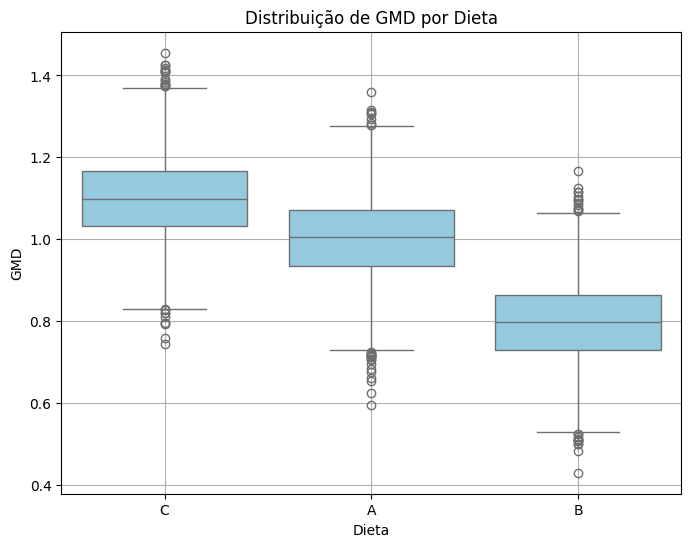

,sum_sq,df,F,PR(>F)
C(Dieta),187.398635,2.0,9205.215322,0.0
Residual,122.116721,11997.0,NaN,NaN


In [ ]:
#===============================================================================
#     Simular Dados de Exemplo (Sampling Data)
#===============================================================================

np.random.seed(42)
n = 60

dietas = np.random.choice(['A', 'B', 'C'], size=num_animais)
dados = []

for dieta in dietas:
    if dieta == 'A':
        gmd = np.random.normal(1.0, 0.1, n)
    elif dieta == 'B':
        gmd = np.random.normal(0.8, 0.1, n)
    else:
        gmd = np.random.normal(1.1, 0.1, n)
    for valor in gmd:
        dados.append({'Dieta': dieta, 'GMD': valor})

ds = pd.DataFrame(dados)
ds.head()

# Visualização
plt.figure(figsize=(8,6))
sns.boxplot(x='Dieta', y='GMD', data=ds, color='skyblue')
plt.title('Distribuição de GMD por Dieta')
plt.grid(True)
plt.show()

# ANOVA com Statsmodels
modelo = ols('GMD ~ C(Dieta)', data=ds).fit()
anova_resultado = sm.stats.anova_lm(modelo, typ=2)
anova_resultado

**Interpretação do teste ANOVA**

*   F = 9205.22: Um valor tão alto sugere fortes diferenças entre os grupos.

*   p-valor = 0.0: O valor praticamente zero indica que a chance de essas diferenças ocorrerem ao acaso é mínima (praticamente nula).


*   O teste ANOVA não diz quais grupos são diferentes. Para isso, usamos um teste pós-hoc, como o Tukey HSD, para identificar quais pares de grupos que diferem.



In [ ]:
#=========================================================================================
#     Teste Tukey HSD (para indicar qual dieta é diferente)
#     É um teste post hoc usado após a realização de um ANOVA com resultado significativo.
#     Seu principal objetivo é:dentificar quais pares de grupos (ex: dietas A, B e C)
#     possuem diferenças estatisticamente significativas entre suas médias.
#=========================================================================================

from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(df['GMD_medio'], df['Dieta'])
print(tukey)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
     A      B  -0.1945   0.0 -0.2553 -0.1336   True
     A      C   0.1189   0.0  0.0606  0.1771   True
     B      C   0.3133   0.0  0.2539  0.3728   True
---------------------------------------------------



*  A média de GMD da dieta A é maior que B em cerca de **0.19** kg/dia. Como o p-valor é 0.0, essa diferença é estatisticamente significativa, ou seja, a dieta A é superior à dieta B em termos de ganho médio diário. Como o p-valor é < 0.05 a diferença é estatisticamente significativa.

*   A x C: A média de GMD da dieta C é maior que A em cerca de **0.12** kg/dia, a diferença também estatisticamente significativa.

*   B x C: A dieta C é muito superior à dieta B em GMD, com diferença de **0.31** kg/dia, também estatisticamente significativa

*   A ordem de desempenho em GMD é: **Dieta C > Dieta A > Dieta B**, isso reforça que **a dieta C** promove maior desempenho animal em comparação com as demais.

*   **Justifica adoção preferencial da dieta C.**



# 6. Teste de Hipóteses

Vamos fazer os teste de hipoteses entre grupo "**descarte**" e "**nao-descarte**" considerando as variáveis **GMD_medio, ICA e CustoTotal** para validar estatisticamente o critério de descarte. Desta forma fazemos testes diferentes daquele do Delineamento de Experimentos acima. Serão dois grupos e portanto portanto poderemos utilizar o test **t-student**.

**Passo 1** - **Que teste utilizar?**

*   **t-test**: Comparar 2 grupos apenas (Descarte **x** Não-Descarte)

**Passo 2 -  Requisitos para o t-test**

*   Normalidade dos resíduos em cada grupo → Teste de Shapiro-Wilk ✅
*   Homogeneidade de variâncias → Teste de Levene ✅
*  Independência das observações: garantida pelo desenho experimental (um animal não influencia outro. ✅

**Passo 3 - Formulação das hipótese H0 e H1**

**Ganho Medio de Peso Diário (GMD_medio)**
*   **Hipótese Nula (𝐻0)**: O GMD_medio é a mesma entre os descartados e não descartados. : 𝜇𝐴 =𝜇𝐵 =𝜇𝐶
*   **Hipótese Alternativa (H₁)**: Pelo menos um GMD_medio é diferente: H1 ​: μi dif μj para algum i dif j

**Indice de Conversão Alimentar (ICA)**
*   **Hipótese Nula (𝐻0)**: O (ICA) é a mesma entre os descartados e não descartados. : 𝜇𝐴 =𝜇𝐵 =𝜇𝐶
*   **Hipótese Alternativa (H₁)**: Pelo menos um ICA é diferente: H1 ​: μi dif μj para algum i dif j

**Custo Total (CustoTotal)**
*   **Hipótese Nula (𝐻0)**: O CustoTotal é omesmo entre os descartados e não descartados. : 𝜇𝐴 =𝜇𝐵 =𝜇𝐶
*   **Hipótese Alternativa (H₁)**: Pelo menos um CustoTotal é diferente: H1 ​: μi dif μj para algum i dif j

**Passo 4 - Separar os Grupos**: Aplicar o teste de comparações múltiplas de Tukey HSD para identificar quais pares de dietas são significativamente diferentes.

**Passo 5 - Verificar os requisitos para o t-test**

**Passo 6 - Executar o t-test**

In [ ]:
#===============================================================================
#                 Teste Shapiro-Wilky
#===============================================================================

# Separar os grupos (Descarte e não descarte)

grupo_sim = df[df['Descarte'] == 'Sim']
grupo_nao = df[df['Descarte'] == 'Não']

variaveis = ['GMD_medio', 'ICA', 'CustoPorKgGanho']

resultados = []

for var in variaveis:
    dados_sim = grupo_sim[var].dropna()
    dados_nao = grupo_nao[var].dropna()

    if len(dados_sim) >= 3:
        stat_sim, p_sim = shapiro(dados_sim)
    else:
        stat_sim, p_sim = (None, None)

    if len(dados_nao) >= 3:
        stat_nao, p_nao = shapiro(dados_nao)
    else:
        stat_nao, p_nao = (None, None)

    resultados.append({
        'Variável': var,
        'Grupo': 'Descarte = Sim',
        'N': len(dados_sim),
        'W': round(stat_sim, 4) if stat_sim is not None else '—',
        'p-valor': round(p_sim, 5) if p_sim is not None else '—',
        'Normal?': 'Sim' if p_sim is not None and p_sim > 0.05 else 'Não'
    })

    resultados.append({
        'Variável': var,
        'Grupo': 'Descarte = Não',
        'N': len(dados_nao),
        'W': round(stat_nao, 4) if stat_nao is not None else '—',
        'p-valor': round(p_nao, 5) if p_nao is not None else '—',
        'Normal?': 'Sim' if p_nao is not None and p_nao > 0.05 else 'Não'
    })

df_shapiro = pd.DataFrame(resultados)
display(df_shapiro)

,Variável,Grupo,N,W,p-valor,Normal?
0,GMD_medio,Descarte = Sim,97,0.9847,0.32198,Sim
1,GMD_medio,Descarte = Não,103,0.9726,0.03083,Não
2,ICA,Descarte = Sim,97,0.9543,0.00197,Não
3,ICA,Descarte = Não,103,0.9036,0.00000,Não
4,CustoPorKgGanho,Descarte = Sim,97,0.9904,0.71377,Sim
5,CustoPorKgGanho,Descarte = Não,103,0.9163,0.00001,Não


In [ ]:
# Reload the original dataframe from the saved CSV
df = pd.read_csv("Dataset_Bovinos_de_Corte.csv")

In [ ]:
# Teste de homogeneidade de variâncias (Levene)

for var in variaveis:
    stat, p = levene(grupo_sim[var], grupo_nao[var])
    print(f"\n Levene para {var}: stat={stat:.3f}, p={p:.4f}")


 Levene para GMD_medio: stat=5.710, p=0.0178

 Levene para ICA: stat=9.031, p=0.0030

 Levene para CustoPorKgGanho: stat=17.374, p=0.0000


<table>
  <tr>
    <th>Variável</th>
    <th>Estatística F</th>
    <th>p-valor</th>
    <th>Interpretação Prática</th>
  </tr>
  <tr>
    <td>GMD_medio</td>
    <td>5.710</td>
    <td>0.0178</td>
    <td>❌ Rejeita H₀ → Variâncias diferentes entre dietas</td>
  <tr>
    <td>ICA</td>
    <td>9.031</td>
    <td>0.0030</td>
    <td>❌ Rejeita H₀ → Variâncias diferentes entre dietas</td>
  </tr>
     <td>CustoTotal</td>
    <td>4.014</td>
    <td>0.465</td>
    <td>❌ Rejeita H₀ → Variâncias diferentes entre dietas</td>
  </tr>

  <table>
  <td>O teste de Levene indica que as variâncias não são homogêneas para todas as três variáveis.</td>
  </tr>
  </tr>
    <td>Evitar t de Student e usar o teste t de Welch (com equal_var=False), que não assume variâncias iguais</td>
  </tr>

In [ ]:
#===============================================================================
#       Teste t de Welch (variância desiguais)
#===============================================================================

from scipy.stats import ttest_ind, mannwhitneyu, shapiro

variaveis = ['GMD_medio', 'ICA', 'CustoTotal']
grupo_sim = df[df['Descarte'] == 'Sim']
grupo_nao = df[df['Descarte'] == 'Não']

print("📊 Comparação entre grupos: Descarte = Sim vs Não\n")

for var in variaveis:
    dados_sim = grupo_sim[var].dropna()
    dados_nao = grupo_nao[var].dropna()

    n1 = len(dados_sim)
    n2 = len(dados_nao)

    print(f"🔎 {var} — n1 = {n1}, n2 = {n2}")

    if n1 < 2 or n2 < 2:
        print("⚠️ Dados insuficientes para teste estatístico.\n")
        continue

    # Testar normalidade nos dois grupos
    p_norm1 = shapiro(dados_sim).pvalue
    p_norm2 = shapiro(dados_nao).pvalue
    normal = p_norm1 > 0.05 and p_norm2 > 0.05

    if normal:
        t_stat, p_valor = ttest_ind(dados_sim, dados_nao, equal_var=False)
        teste = "Teste t de Welch"
    else:
        t_stat, p_valor = mannwhitneyu(dados_sim, dados_nao, alternative='two-sided')
        teste = "Mann-Whitney U"

    print(f" {teste}: estatística = {t_stat:.4f}, p = {p_valor:.5f}")
    if p_valor <= 0.05:
        print(" Diferença **significativa** entre os grupos.\n")
    else:
        print(" Diferença **não significativa** entre os grupos.\n")



📊 Comparação entre grupos: Descarte = Sim vs Não

🔎 GMD_medio — n1 = 97, n2 = 103
 Mann-Whitney U: estatística = 1304.0000, p = 0.00000
 Diferença **significativa** entre os grupos.

🔎 ICA — n1 = 97, n2 = 103
 Mann-Whitney U: estatística = 4802.0000, p = 0.63708
 Diferença **não significativa** entre os grupos.

🔎 CustoTotal — n1 = 97, n2 = 103
 Teste t de Welch: estatística = -9.8480, p = 0.00000
 Diferença **significativa** entre os grupos.



**Análise dos resultados**

*   GMD-Medio: O valor-p é muito menor que 0.05 → rejeitamos H₀. Há diferença estatisticamente significativa entre os grupos em termos de ganho médio diário (GMD). Isso confirma que o critério de descarte baseado em GMD está estatisticamente validado.

*   ICA: O valor-p é maior que 0.05 → não rejeitamos H₀. Não há evidência de que animais descartados tenham ICA significativamente diferente. Isso não invalida o uso do ICA como critério, mas sugere que o limiar usado (ex: ICA > 9.0) pode estar muito permissivo ou não separa bem os grupos.

*   CustoTotal: Valor-p << 0.05 → rejeitamos H₀. Há diferença estatisticamente significativa entre os grupos. Isso sugere que animais descartados também geraram maior custo total, reforçando a validade do descarte por razões econômicas.

<table>
  <tr>
    <th>Variável</th>
    <th>t</th>
    <th>p-valor</th>
    <th>Interpretação Prática</th>
  </tr>
  <tr>
    <td>GMD_medio</td>
    <td>-11.02</td>
    <td>0.0000</td>
    <td>✅ A média de GMD é significativamente menor no grupo "Descarte"</td>
  <tr>
    <td>ICA</td>
    <td>-0.68</td>
    <td>0.4972</td>
    <td>	🚫 Não há diferença significativa entre os grupos (ICA não é decisivo)</td>
  </tr>
     <td>CustoTotal</td>
    <td>-9.85</td>
    <td>0.0000</td>
    <td>✅ O custo total médio é significativamente maior no grupo "Descarte"</td>
  </tr>


Esses valores negativos  de "t" sāo explicados pela fórmula de cálculo **t= (media do grupo1 (descarte) - media do grupo2(não descarte) / erro padrão**. Mesmo raciocínio se aplica as variáveis ICA e CustTotal


*   **GMD_medio**: animais descartados têm GMD médio significativamente menor

*   **ICA**: não é possível afirmar que o ICA influencia o descarte
*   **CustoTotal**: O valor negativo indica que a média do grupo1 (Descarte = Sim) é menor que a do grupo2 (não descarte) e deve ser utilizado como critério de descarte


# 7 Análise dos Dados

In [ ]:
#===============================================================================
#   Informaçōes do dataset animal
#===============================================================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   AnimalID         200 non-null    int64  
 1   Dieta            200 non-null    object 
 2   PesoInicial      200 non-null    float64
 3   PesoFinal        200 non-null    float64
 4   GMD_medio        200 non-null    float64
 5   z_score          200 non-null    float64
 6   ICA              200 non-null    float64
 7   Media_GMD_Dieta  200 non-null    float64
 8   DP_GMD_Dieta     200 non-null    float64
 9   Limiar_GMD       200 non-null    float64
 10  CustoDieta       200 non-null    float64
 11  ConsumoTotalMS   200 non-null    float64
 12  CustoTotal       200 non-null    float64
 13  CustoPorKgGanho  200 non-null    float64
 14  Receita          200 non-null    float64
 15  MargemBruta      200 non-null    float64
 16  Descarte         200 non-null    object 
dtypes: float64(14), 

In [ ]:
#==========================================================
# Verificar duplicações de registros no Dataset.
#==========================================================

duplicated_count = df.duplicated().sum()
print("Quantidade de dados duplicados:", duplicated_count)

Quantidade de dados duplicados: 0


In [ ]:
#=======================================================
# Verifica a quantidade de valores unicos das variáveis
#=======================================================

df.nunique()

,0
AnimalID,200
Dieta,3
PesoInicial,200
PesoFinal,200
GMD_medio,200
z_score,200
ICA,200
Media_GMD_Dieta,3
DP_GMD_Dieta,3
Limiar_GMD,3


In [ ]:
# =========================================================================
#     Amostra do dataframe
# =========================================================================
print(df.head(20))

    AnimalID Dieta  PesoInicial   PesoFinal  GMD_medio   z_score       ICA  \
0          1     C   324.230170  396.798933   1.229979  1.287324  8.679969   
1          2     A   303.893535  360.429463   0.958236 -0.118343  6.439939   
2          3     C   315.234925  372.183990   0.965238 -0.082121  8.352651   
3          4     C   314.812564  377.680411   1.065557  0.436803  7.891231   
4          5     A   341.778256  405.123544   1.073649  0.478663  6.112689   
5          6     A   342.736235  407.859707   1.103788  0.634563  6.728854   
6          7     C   308.885216  366.992250   0.984865  0.019403  8.890555   
7          8     B   359.864429  416.219684   0.955174 -0.134183  7.519090   
8          9     C   316.006861  376.286636   1.021691  0.209896  8.594261   
9         10     C   358.596897  421.561532   1.067197  0.445289  8.907057   
10        11     C   324.662221  395.965430   1.208529  1.176367  9.236153   
11        12     C   301.983044  372.608335   1.197039  1.116931

In [ ]:
#==================================================================
#   Linhas e colunas do dataset
#==================================================================

df.shape

(200, 17)

In [ ]:
#===========================================================
# Distribuição da variável "descarte" entre as dietas
#   Mostra que o maior numero de não descarte de animais
#   acontece com aqueles que usam a melhor dieta C (como
#   era o esperado). Existe um equilibrio na
# variável-alvo "descartes".
#==========================================================

df['Descarte'].value_counts().sort_index()

,count
Descarte,
Não,103
Sim,97


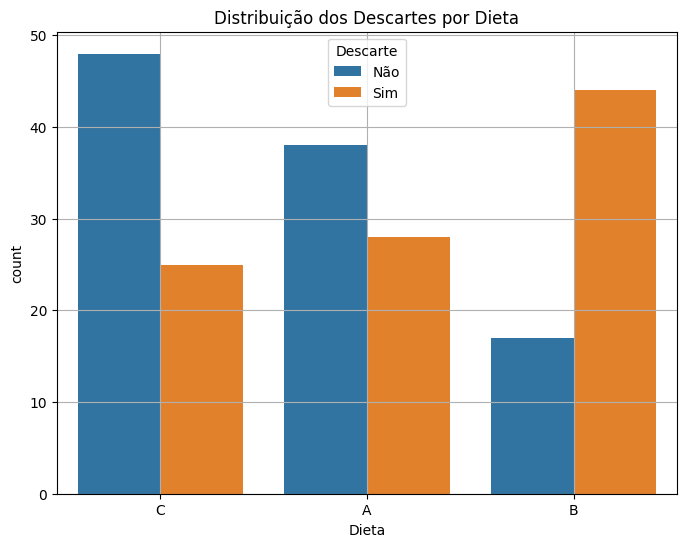

In [ ]:
plt.figure(figsize=(8,6))
sns.countplot(data=df, x='Dieta', hue='Descarte')
plt.title('Distribuição dos Descartes por Dieta')
plt.grid(True)
plt.show()

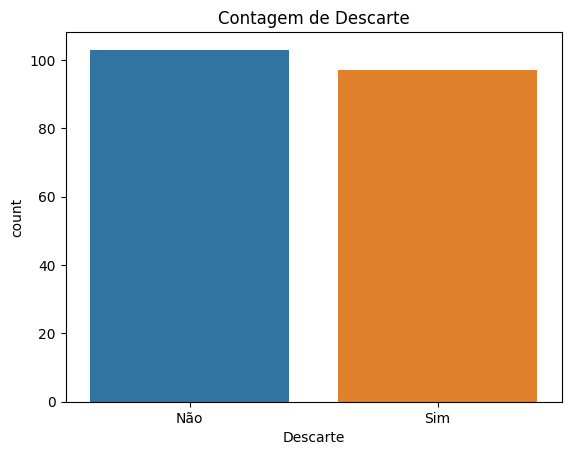

In [ ]:
for column in categorical_columns:
    sns.countplot(data=df, x=column, hue="Descarte")
    plt.title(f"Contagem de {column}")
    plt.show()

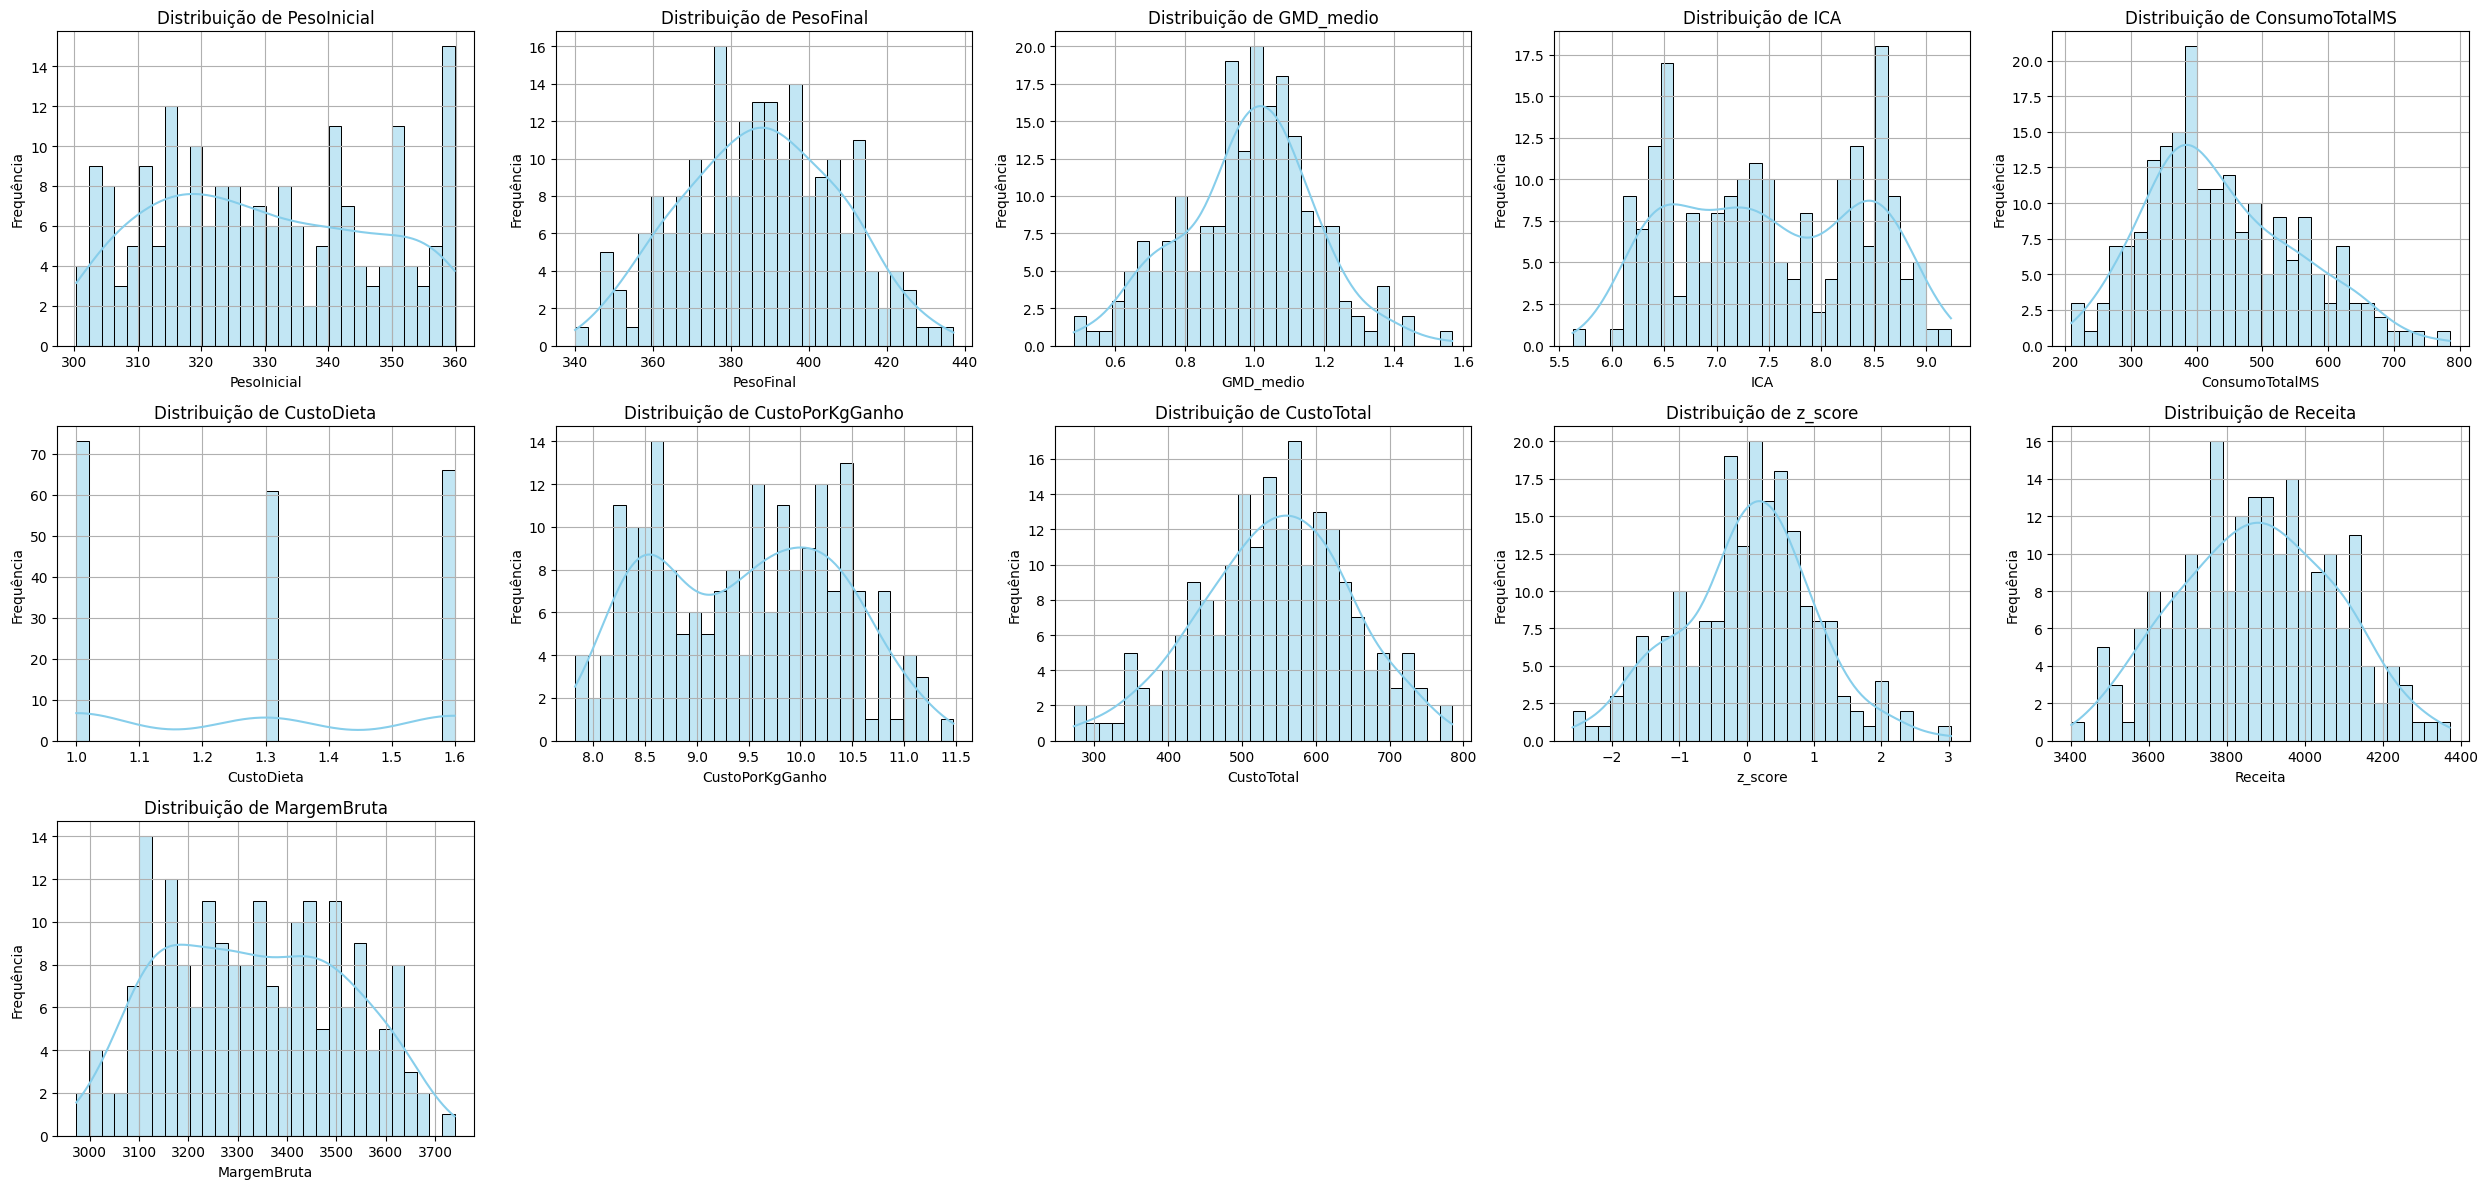

In [ ]:
#===================================================================================
#   Distribuição conjunta de todas as variáveis. É importantes notar que todas elas
#     apresentam uma distrinuição normal. Se a intenção for usar testes não
#     paramétricos podemos utilizar alternativas não paramétricos: Mann-Whitney U,
#     Kruskal-Wallis e outros, ou tentar fazer transformações do tipo o Z-score
#===================================================================================

# Número de colunas por linha
colunas_por_linha = 5

# Número total de variáveis
total = len(variaveis_de_interesse)
linhas = math.ceil(total / colunas_por_linha)

# Tamanho da figura ajustado à quantidade de linhas/colunas
fig, axes = plt.subplots(linhas, colunas_por_linha, figsize=(5 * colunas_por_linha, 4 * linhas))
axes = axes.flatten()  # transforma para vetor 1D para facilitar iteração

# Gera um histograma com KDE para cada variável
for i, coluna in enumerate(variaveis_de_interesse):
    ax = axes[i]
    sns.histplot(data=df, x=coluna, kde=True, bins=30, ax=ax, color='skyblue', edgecolor='black')
    ax.set_title(f'Distribuição de {coluna}', fontsize=12)
    ax.set_xlabel(coluna)
    ax.set_ylabel('Frequência')
    ax.grid(True)

# Remove eixos vazios se houver
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()



In [ ]:
#=================================================================================
#   BoxPlot das variaveis, para resumir a distribuição estatísticas dos dados, para
#   mostrar intervalo interquartil (IQR) e detectar outliers, avaliar assimetria,
#   observar medianas, ideal para as variáveis como o GMD, ICA e CustoTotal
#
#     Box: de Q1 (25%) a Q3 (75%)
#     Linha interna:  mediana (50%)
#     Bigodes: extensão do menor e o maior valor sem outliers
#     Pontos fora: outlies
#     mi: média da amostra/distribuição
#=================================================================================

import math
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Número de colunas por linha
colunas_por_linha = 4

# Inicializa os títulos customizados
subplot_titles = []

# Calcula os títulos com média, n e outliers
for col in variaveis_de_interesse:
    valores = df[col].dropna()
    media = valores.mean()
    n = len(valores)
    q1 = valores.quantile(0.25)
    q3 = valores.quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    outliers = ((valores < lim_inf) | (valores > lim_sup)).sum()

    titulo = f"{col}<br>µ={media:.2f} | n={n} | outliers={outliers}"
    subplot_titles.append(titulo)

# Total de variáveis e número de linhas
total_variaveis = len(variaveis_de_interesse)
linhas = math.ceil(total_variaveis / colunas_por_linha)

# Cria o layout de subplots
fig = make_subplots(
    rows=linhas,
    cols=colunas_por_linha,
    subplot_titles=subplot_titles
)

# Adiciona os boxplots
for i, col in enumerate(variaveis_de_interesse):
    linha = (i // colunas_por_linha) + 1
    coluna = (i % colunas_por_linha) + 1
    fig.add_trace(
        go.Box(y=df[col], name=col, boxpoints='outliers'),
        row=linha, col=coluna
    )

# Ajusta o layout
fig.update_layout(
    title_text="Boxplots com Estatísticas Resumidas",
    title_x=0.5,
    showlegend=False,
    height=400 * linhas,
    width=1200,
    template='plotly_white'
)

fig.show()




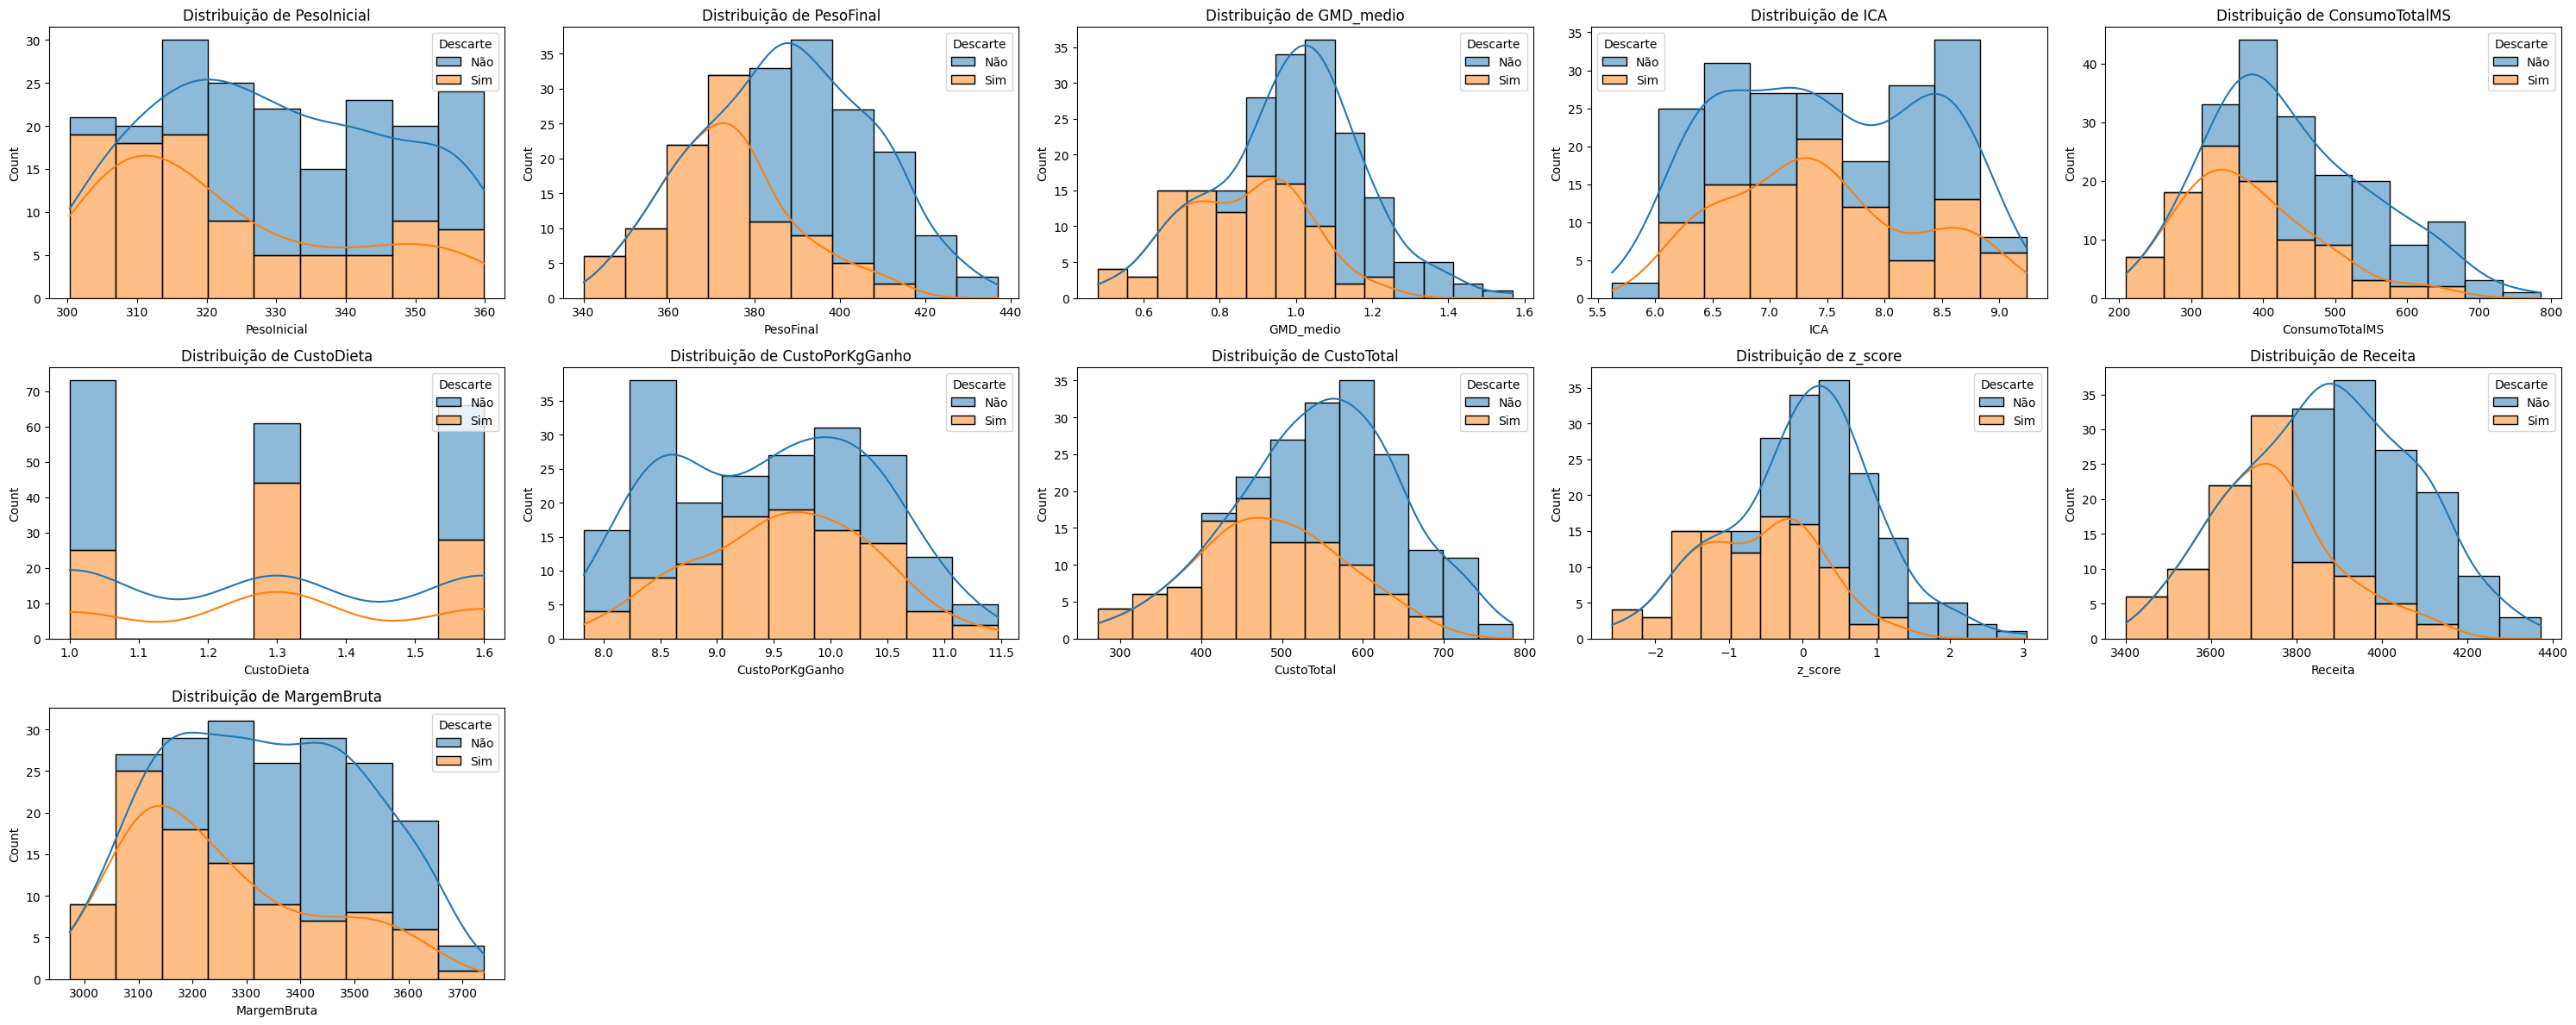

In [ ]:
#===============================================================================
#   Distribuição das variáveis em relação a variável-alvo (Descarte)
#===============================================================================

import matplotlib.pyplot as plt
import seaborn as sns
import math

# Número de colunas que você deseja (ajuste conforme necessário)
n_cols = 5

# Número total de gráficos
n = len(variaveis_de_interesse)

# Calcula número de linhas necessárias (arredonda para cima)
n_rows = math.ceil(n / n_cols)

# Tamanho da figura total (ajuste o tamanho de cada subplot)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
axes = axes.flatten()  # Transforma os eixos em uma lista para facilitar a iteração

# Loop pelas variáveis e gera os histogramas
for i, column in enumerate(variaveis_de_interesse):
    sns.histplot(data=df, x=column, hue="Descarte", multiple="stack", kde=True, ax=axes[i])
    axes[i].set_title(f"Distribuição de {column}")

# Remove subplots vazios (caso o número de variáveis seja menor que n_rows * n_cols)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


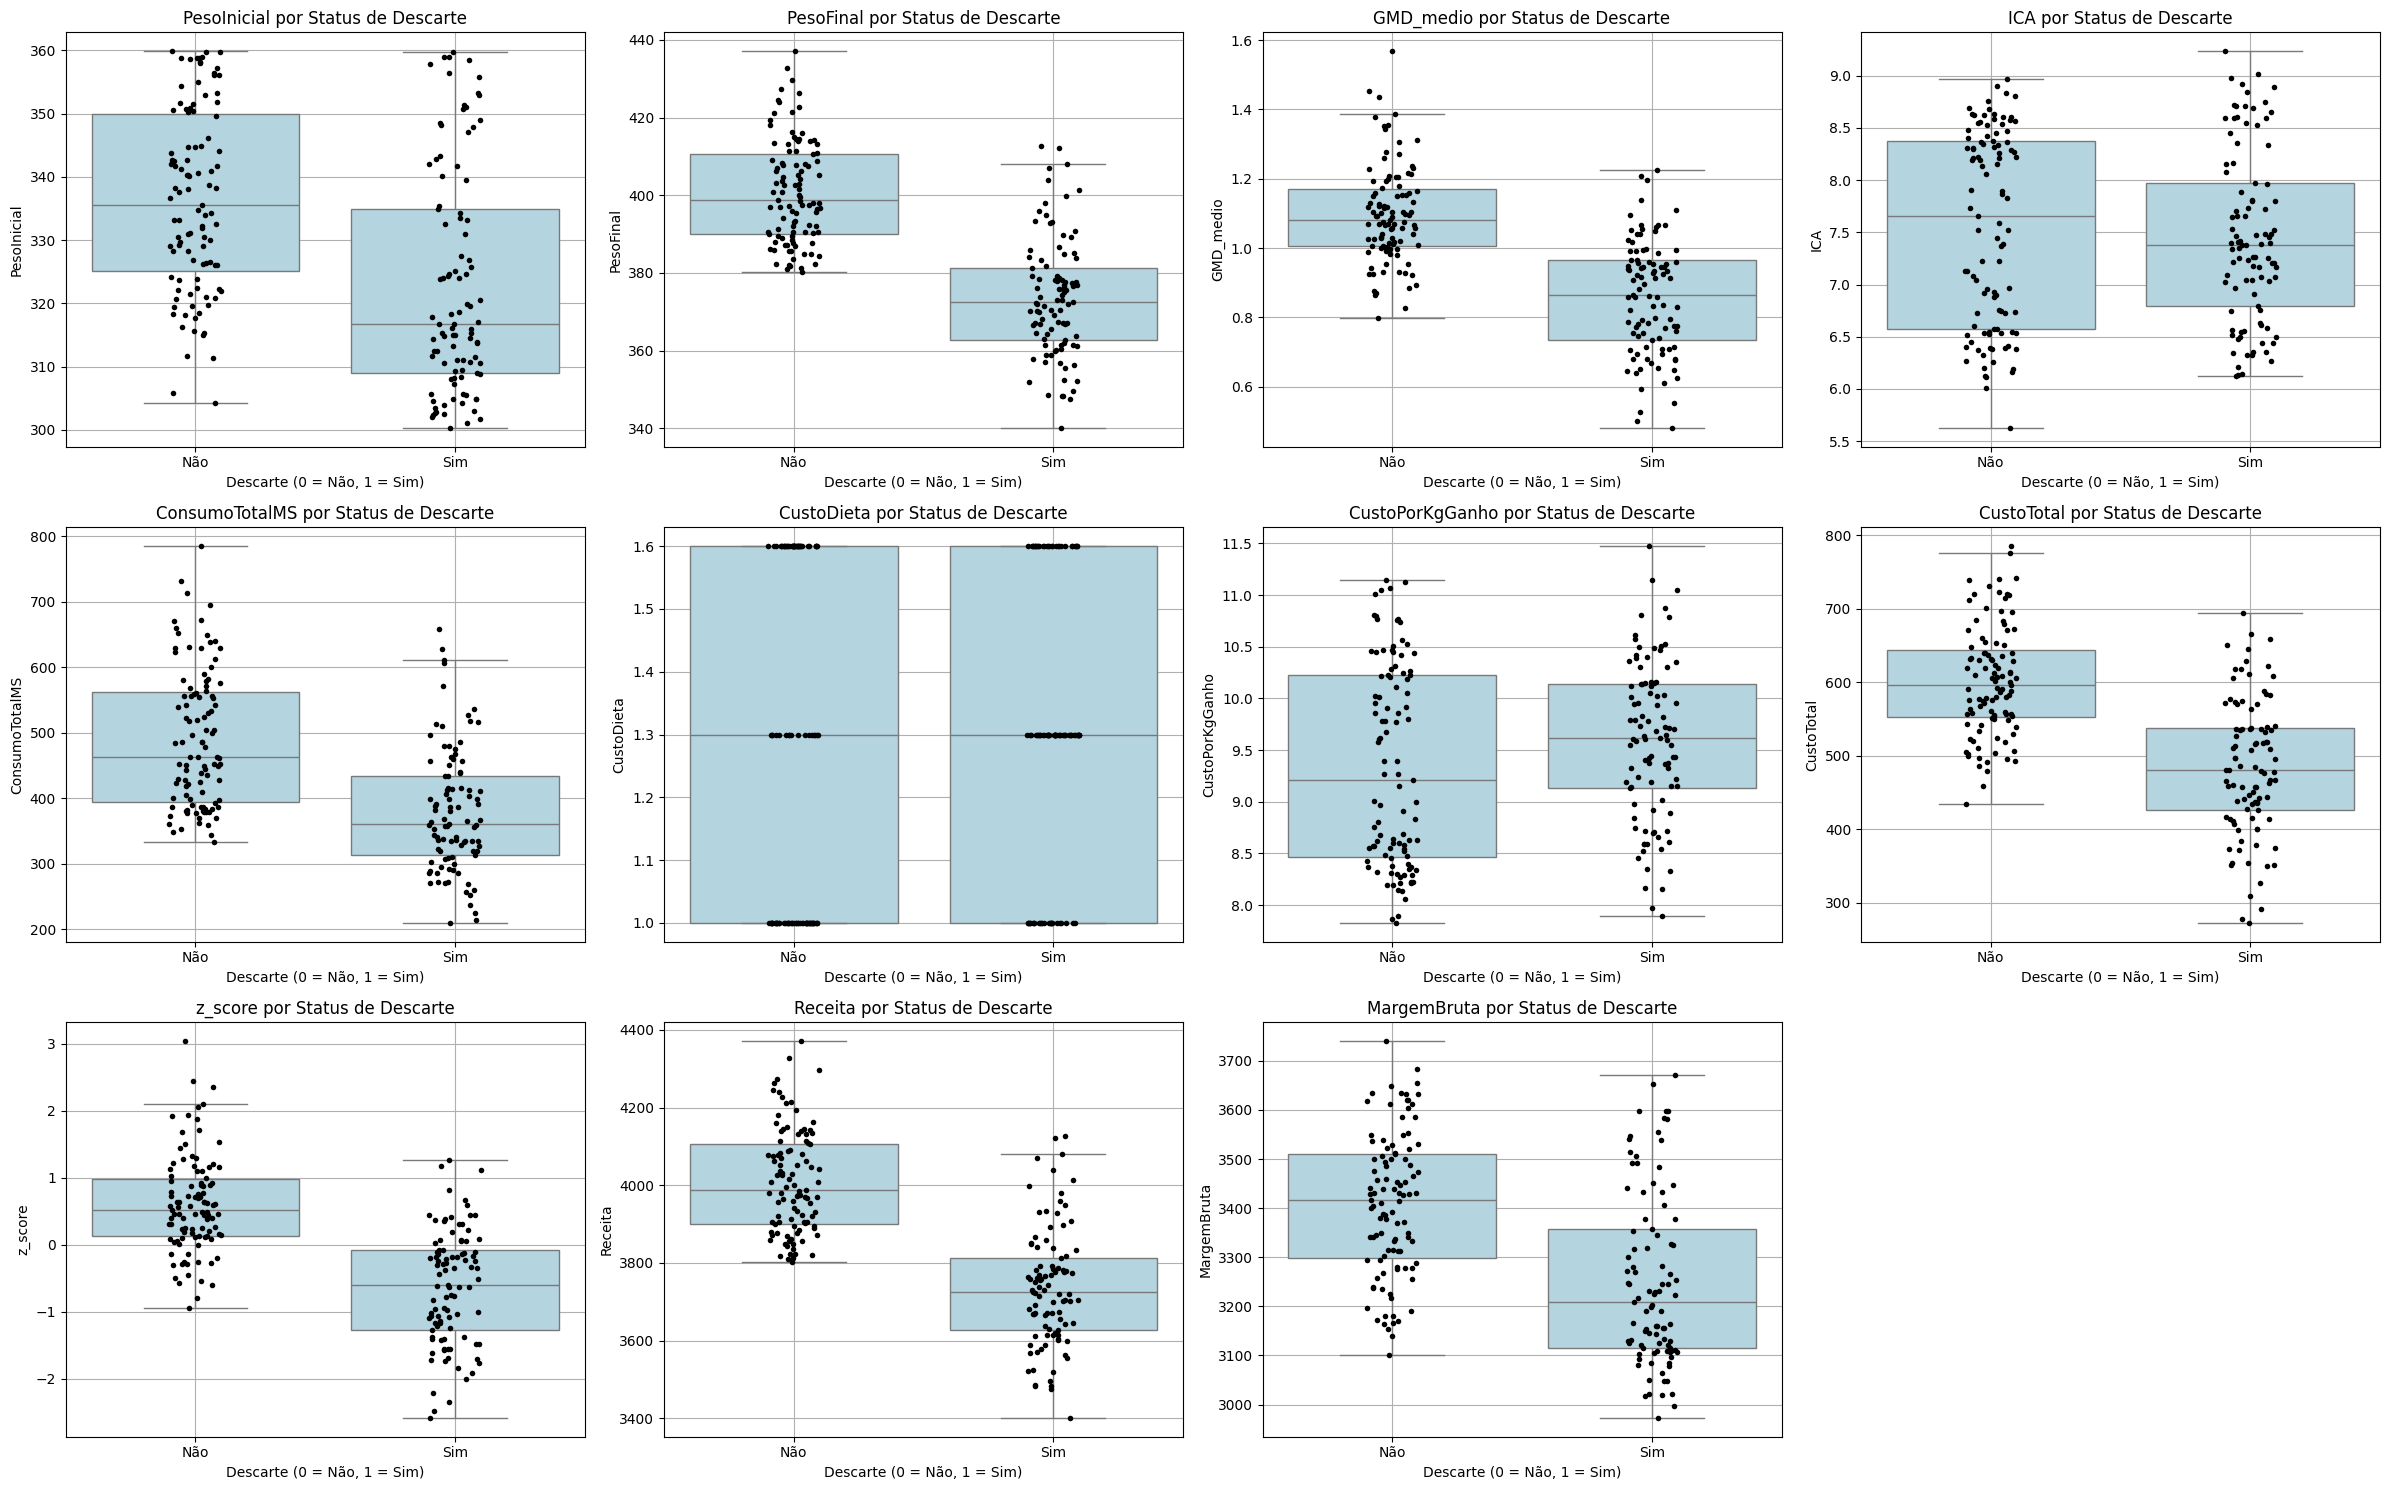

In [ ]:
#===============================================================================
#   Boxplot da variáveis em relação a variável-alvo. Aqui pode-se
#   claramente os ouliers. Optamos por nã elimina-los do dataset
#   Vantagens: Reduz a distorção das médias e variâncias, que podem inflar médias
#               e desvios-padrão e ajuda no desempenho de algoritmos de ML
#   Desvantagens: perda de informações importantes, viés na análise e pode
#               afetar a representatividade
#===============================================================================

import matplotlib.pyplot as plt
import seaborn as sns
import math

# Definir grid
n_col = 4
n_row = math.ceil(len(variaveis_de_interesse) / n_col)

plt.figure(figsize=(n_col * 6, n_row * 5))

for i, column in enumerate(variaveis_de_interesse, 1):
    plt.subplot(n_row, n_col, i)

    sns.boxplot(
        data=df,
        x='Descarte',
        y=column,
        color='lightblue',
        showfliers=False
    )

    sns.stripplot(
        data=df,
        x='Descarte',
        y=column,
        color='black',
        size=4,
        jitter=True
    )

    plt.title(f'{column} por Status de Descarte')
    plt.xlabel('Descarte (0 = Não, 1 = Sim)')
    plt.ylabel(column)
    plt.grid(True)

plt.tight_layout()
plt.show()



In [ ]:
# Exportar o dataset .CSV no arquivo local
df.to_csv("Dataset_Bovinos_de_Corte.csv", index=False)
print("Arquivo 'Dataset_Bovinos_de_Corte.csv' gerado com sucesso!")

Arquivo 'Dataset_Bovinos_de_Corte.csv' gerado com sucesso!


# 7.1 Aplicação dos Testes Estatísticos

In [ ]:
variaveis_de_interesse2 = ['GMD_medio','ICA','CustoPorKgGanho','CustoTotal']

In [ ]:
#===============================================================================
#     ??????
#===============================================================================

# Separar grupos
grupo_sim = df[df['Descarte'] == 1]['GMD_medio'].dropna()
grupo_nao = df[df['Descarte'] == 0]['GMD_medio'].dropna()

print(f"Tamanho grupo Sim: {len(grupo_sim)}")
print(f"Tamanho grupo Não: {len(grupo_nao)}")

if len(grupo_sim) >= 3 and len(grupo_nao) >= 3:
    # Continue com os testes...
    pass
else:
    print(" Um dos grupos tem menos de 3 dados não nulos. Teste estatístico inválido.")

# Verificar normalidade
print(' Shapiro-Wilk:')
print('  Sim :', shapiro(grupo_sim))
print('  Não :', shapiro(grupo_nao))

# Verificar homogeneidade de variância
print('\n Levene (homogeneidade):', levene(grupo_sim, grupo_nao))

# Aplicar o teste adequado
p_sim = shapiro(grupo_sim).pvalue
p_nao = shapiro(grupo_nao).pvalue

if p_sim > 0.05 and p_nao > 0.05:
    # Normalidade OK → avaliar variância
    stat_levene, p_levene = levene(grupo_sim, grupo_nao)
    if p_levene > 0.05:
        print("\n✅ Teste t padrão (variâncias iguais)")
        t_stat, p_valor = ttest_ind(grupo_sim, grupo_nao, equal_var=True)
    else:
        print("\n Teste t de Welch (variâncias diferentes)")
        t_stat, p_valor = ttest_ind(grupo_sim, grupo_nao, equal_var=False)
else:
    print("\n Teste Mann-Whitney (dados não normais)")
    t_stat, p_valor = mannwhitneyu(grupo_sim, grupo_nao, alternative='two-sided')

print(f'Resultado: estatística = {t_stat:.4f}, p = {p_valor:.5f}')

Tamanho grupo Sim: 97
Tamanho grupo Não: 103
 Shapiro-Wilk:
  Sim : ShapiroResult(statistic=np.float64(0.9846937712973306), pvalue=np.float64(0.3219800404917388))
  Não : ShapiroResult(statistic=np.float64(0.9726016375724524), pvalue=np.float64(0.030834684709691005))

 Levene (homogeneidade): LeveneResult(statistic=np.float64(5.710197004565686), pvalue=np.float64(0.017804908594934478))

 Teste Mann-Whitney (dados não normais)
Resultado: estatística = 1304.0000, p = 0.00000


A tabela estatísticas (parcialmente exibida) armazenamos as estatísticas calculadas para cada animal. Com isso, podemos identificar animais com GMD muito baixo comparado ao grupo. Por exemplo, um animal com 𝑧 -score de -2,0 possui um ganho médio diário 2 desvios-padrão abaixo da média do lote, sendo um forte candidato a descarte.

Também realizamos um teste t de Student (amostras independentes) para verificar se existe diferença significativa no ganho de peso médio entre os animais descartados e não descartados. Para isso, consideramos as distribuições de GMD por animal em cada grupo (isto é, cada animal contribui com seu ganho de peso médio nos 30 dias). Formulamos as hipóteses:  𝐻0 : Os animais descartados e não descartados têm mesmo ganho de peso médio (diferença de médias = 0).  𝐻1 : Há uma diferença significativa no ganho de peso médio entre os dois grupos.

Condicoes para o teste t:

distribuição normal
variâncias iguais
amostras independentes

In [ ]:
# Converte os valores da coluna Descarte: 'Sim' → 1, 'Não' → 0
df['Descarte'] = df['Descarte'].map({'Sim': 1, 'Não': 0})


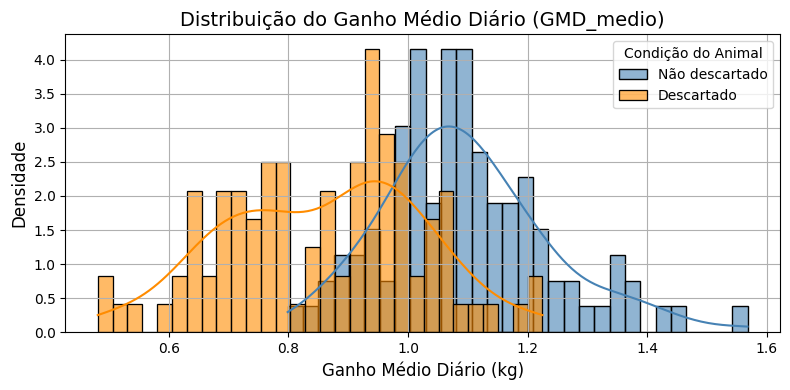

In [ ]:
plt.figure(figsize=(8, 4))

# Distribuição para não descartados
sns.histplot(df[df['Descarte'] == 0]['GMD_medio'],
             color='steelblue', label='Não descartado', kde=True,
             stat='density', bins=30, edgecolor='black', alpha=0.6)

# Distribuição para descartados
sns.histplot(df[df['Descarte'] == 1]['GMD_medio'],
             color='darkorange', label='Descartado', kde=True,
             stat='density', bins=30, edgecolor='black', alpha=0.6)

# Ajustes de layout
plt.title('Distribuição do Ganho Médio Diário (GMD_medio)', fontsize=14)
plt.xlabel('Ganho Médio Diário (kg)', fontsize=12)
plt.ylabel('Densidade', fontsize=12)
plt.legend(title='Condição do Animal')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
#===============================================================================
# 1️⃣     Comparação medias
#===============================================================================

for var in variaveis:
    grupos = [g[var].dropna() for name, g in df.groupby("Dieta")]
    print(f"\nComparação entre dietas para {var}:")
    if all(shapiro(g)[1] > 0.05 for g in grupos):
        stat, p = f_oneway(*grupos)
        print(f"ANOVA: F={stat:.4f}, p={p:.4f}")
        if p < 0.05:
            tukey = pairwise_tukeyhsd(endog=df[var], groups=df['Dieta'], alpha=0.05)
            print(tukey)
    else:
        stat, p = kruskal(*grupos)
        print(f"Kruskal-Wallis: H={stat:.4f}, p={p:.4f}")


Comparação entre dietas para GMD_medio:
ANOVA: F=78.0238, p=0.0000
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
     A      B  -0.1945   0.0 -0.2553 -0.1336   True
     A      C   0.1189   0.0  0.0606  0.1771   True
     B      C   0.3133   0.0  0.2539  0.3728   True
---------------------------------------------------

Comparação entre dietas para ICA:
ANOVA: F=860.4860, p=0.0000
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj lower  upper  reject
-------------------------------------------------
     A      B   0.9212   0.0 0.8025   1.04   True
     A      C   1.9899   0.0 1.8763 2.1034   True
     B      C   1.0686   0.0 0.9527 1.1846   True
-------------------------------------------------

Comparação entre dietas para CustoTotal:
ANOVA: F=57.9946, p=0.0000
   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2  meandiff p-

In [ ]:
# ==============================================================================
# 2️⃣ Verificação de normalidade (Shapiro-Wilk)
# ==============================================================================

variaveis = ['GMD_medio', 'ICA', 'CustoTotal']
for var in variaveis:
    stat, p = shapiro(df[var])
    print(f"🔍 Shapiro-Wilk para {var}: W={stat:.4f}, p={p:.4f} => {'Normal' if p > 0.05 else 'Não Normal'}")

🔍 Shapiro-Wilk para GMD_medio: W=0.9912, p=0.2685 => Normal
🔍 Shapiro-Wilk para ICA: W=0.9468, p=0.0000 => Não Normal
🔍 Shapiro-Wilk para CustoTotal: W=0.9938, p=0.5782 => Normal


In [ ]:
# ==============================================================================
# 3️⃣ Teste de homogeneidade da variância (Levene entre dietas)
# ==============================================================================

for var in variaveis:
    grupos = [g[var].dropna() for name, g in df.groupby("Dieta")]
    stat, p = levene(*grupos)
    print(f" Levene para {var} por Dieta: stat={stat:.4f}, p={p:.4f}")

 Levene para GMD_medio por Dieta: stat=0.8225, p=0.4408
 Levene para ICA por Dieta: stat=0.3132, p=0.7315
 Levene para CustoTotal por Dieta: stat=1.2997, p=0.2749


In [ ]:
# ==============================================================================
# 4️⃣ Comparação de médias por dieta (ANOVA ou Kruskal-Wallis)
# ==============================================================================

for var in variaveis:
    grupos = [g[var].dropna() for name, g in df.groupby("Dieta")]
    print(f"\nComparação entre dietas para {var}:")
    if all(shapiro(g)[1] > 0.05 for g in grupos):
        stat, p = f_oneway(*grupos)
        print(f"  ANOVA: F={stat:.4f}, p={p:.4f}")
        if p < 0.05:
            tukey = pairwise_tukeyhsd(endog=df[var], groups=df['Dieta'], alpha=0.05)
            print(tukey)
    else:
        stat, p = kruskal(*grupos)
        print(f"  Kruskal-Wallis: H={stat:.4f}, p={p:.4f}")


Comparação entre dietas para GMD_medio:
  ANOVA: F=78.0238, p=0.0000
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
     A      B  -0.1945   0.0 -0.2553 -0.1336   True
     A      C   0.1189   0.0  0.0606  0.1771   True
     B      C   0.3133   0.0  0.2539  0.3728   True
---------------------------------------------------

Comparação entre dietas para ICA:
  ANOVA: F=860.4860, p=0.0000
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj lower  upper  reject
-------------------------------------------------
     A      B   0.9212   0.0 0.8025   1.04   True
     A      C   1.9899   0.0 1.8763 2.1034   True
     B      C   1.0686   0.0 0.9527 1.1846   True
-------------------------------------------------

Comparação entre dietas para CustoTotal:
  ANOVA: F=57.9946, p=0.0000
   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2  meand

In [ ]:
# =======================================================================
# 5️⃣ Testes entre grupos de descarte (Sim vs Não)
# ======================================================================

for var in variaveis:
    grupo1 = df[df['Descarte'] == 'Sim'][var].dropna()
    grupo2 = df[df['Descarte'] == 'Não'][var].dropna()
    print(f"\n Comparação para {var} entre Descarte SIM vs NÃO:")
    if shapiro(grupo1)[1] > 0.05 and shapiro(grupo2)[1] > 0.05:
        stat, p = ttest_ind(grupo1, grupo2, equal_var=False)
        print(f"  t-test: t={stat:.4f}, p={p:.4f}")
    else:
        stat, p = mannwhitneyu(grupo1, grupo2)
        print(f"  Mann-Whitney: U={stat:.4f}, p={p:.4f}")


 Comparação para GMD_medio entre Descarte SIM vs NÃO:
  Mann-Whitney: U=nan, p=nan

 Comparação para ICA entre Descarte SIM vs NÃO:
  Mann-Whitney: U=nan, p=nan

 Comparação para CustoTotal entre Descarte SIM vs NÃO:
  Mann-Whitney: U=nan, p=nan


/tmp/ipython-input-498-2242594544.py:9: SmallSampleWarning:

One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.

/tmp/ipython-input-498-2242594544.py:13: SmallSampleWarning:

One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.



In [ ]:
# ==============================================================================
# 6️⃣ Correlação entre GMD, ICA e Custo
# ==============================================================================
from scipy.stats import pearsonr, spearmanr, zscore

print("\n Correlações:")
for x in variaveis:
    for y in variaveis:
        if x != y:
            r1, p1 = pearsonr(df[x], df[y])
            r2, p2 = spearmanr(df[x], df[y])
            print(f"{x} vs {y} ➤ Pearson: r={r1:.2f}, p={p1:.3f} | Spearman: ρ={r2:.2f}, p={p2:.3f}")


 Correlações:
GMD_medio vs ICA ➤ Pearson: r=0.26, p=0.000 | Spearman: ρ=0.24, p=0.001
GMD_medio vs CustoTotal ➤ Pearson: r=0.87, p=0.000 | Spearman: ρ=0.83, p=0.000
ICA vs GMD_medio ➤ Pearson: r=0.26, p=0.000 | Spearman: ρ=0.24, p=0.001
ICA vs CustoTotal ➤ Pearson: r=-0.12, p=0.093 | Spearman: ρ=-0.16, p=0.021
CustoTotal vs GMD_medio ➤ Pearson: r=0.87, p=0.000 | Spearman: ρ=0.83, p=0.000
CustoTotal vs ICA ➤ Pearson: r=-0.12, p=0.093 | Spearman: ρ=-0.16, p=0.021


In [ ]:
# ===============================================================================
# 7️⃣ Outliers (z-score e IQR)
# ==============================================================================
print("\n Outliers:")
for var in variaveis:
    z_scores = np.abs(zscore(df[var]))
    outliers = df[z_scores > 3]
    print(f"{var}: {len(outliers)} outliers com z > 3")


 Outliers:
GMD_medio: 1 outliers com z > 3
ICA: 0 outliers com z > 3
CustoTotal: 0 outliers com z > 3


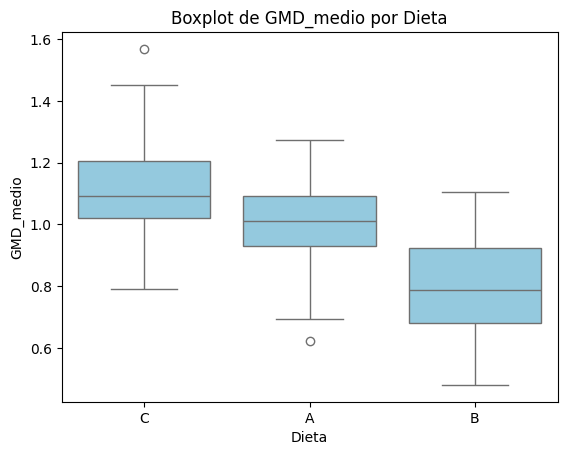

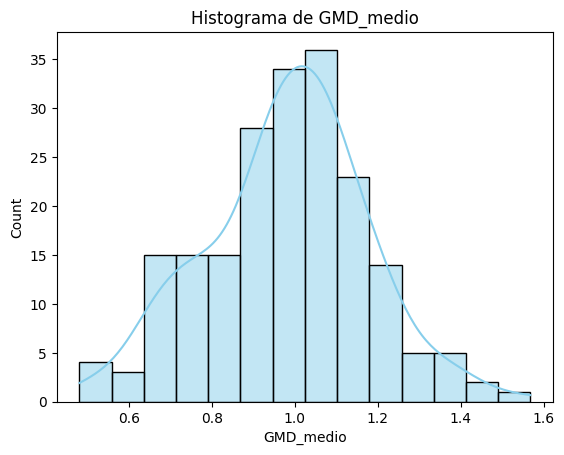

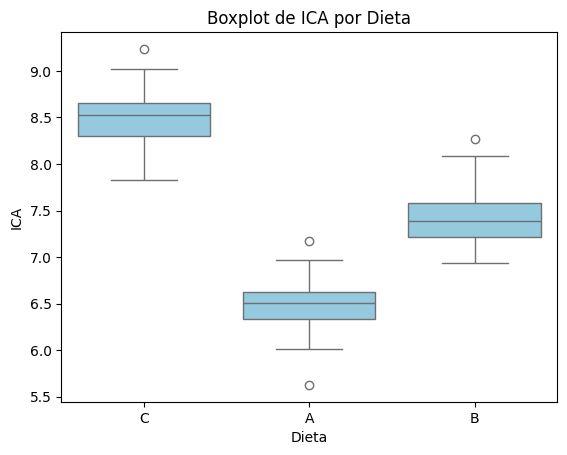

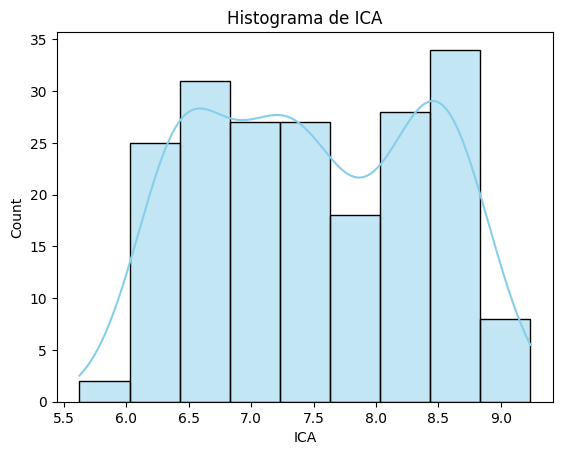

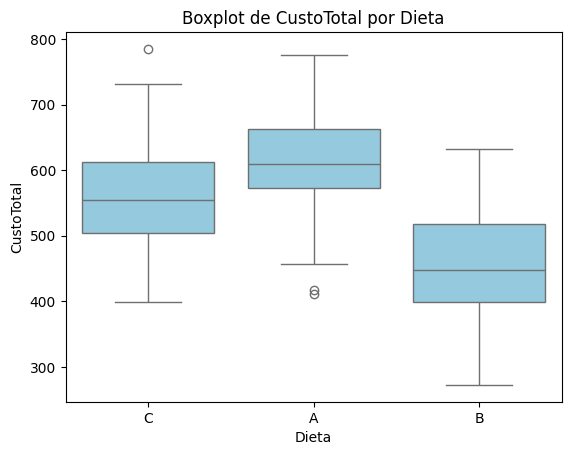

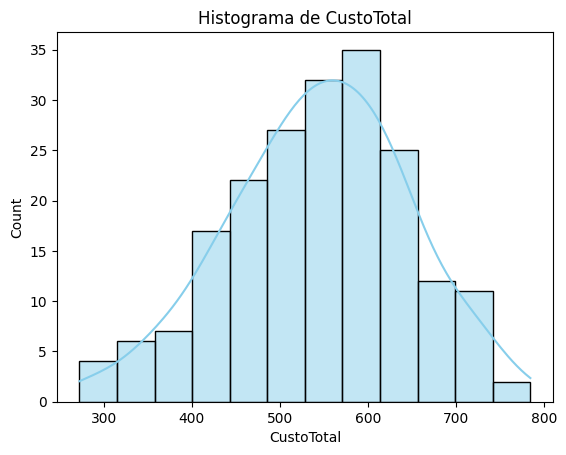

In [ ]:
# ==============================================================================
# 8️⃣ Boxplots e Histogramas
# ==============================================================================

for var in variaveis:
    sns.boxplot(data=df, x='Dieta', y=var, color='skyblue')
    plt.title(f'Boxplot de {var} por Dieta')
    plt.show()

    sns.histplot(df[var], kde=True, color='skyblue')
    plt.title(f'Histograma de {var}')
    plt.show()

In [ ]:
# ==============================================================================
# 9️⃣ Lista sugerida de descarte com base em GMD e ICA
# ==============================================================================

# Critério: GMD abaixo da mediana e ICA acima da mediana

med_gmd = df['GMD_medio'].median()
med_ica = df['ICA'].median()

# Use the boolean condition directly on the original DataFrame
descarte_condition = (df['GMD_medio'] < med_gmd) & (df['ICA'] > med_ica)
descarte_sugestao = df[descarte_condition]

print("\n Sugestão de descarte (baixo GMD e alto ICA):")
display(descarte_sugestao[['AnimalID', 'GMD_medio', 'ICA', 'Dieta']])

# Exibir a tabela
print("Animais descartados:", descarte_sugestao.shape[0])


 Sugestão de descarte (baixo GMD e alto ICA):


,AnimalID,GMD_medio,ICA,Dieta
2,3,0.965238,8.352651,C
6,7,0.984865,8.890555,C
7,8,0.955174,7.519090,B
19,20,0.934082,7.463096,B
27,28,0.948874,8.165594,C
30,31,0.871220,7.524699,B
33,34,0.865629,7.798495,B
35,36,0.753524,7.733386,B
39,40,0.882575,8.456189,C
46,47,0.715817,7.420267,B


Animais descartados: 40


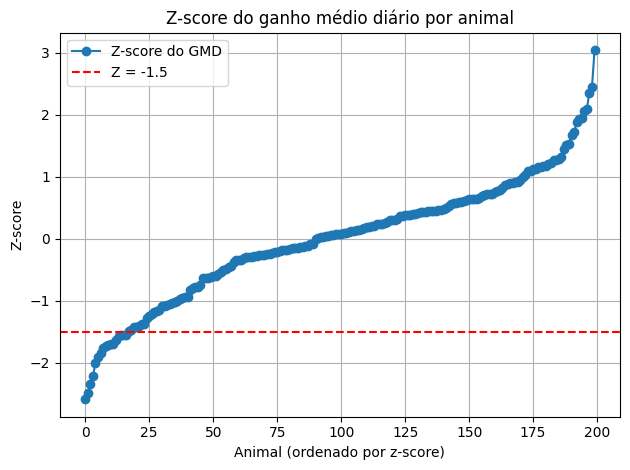

In [ ]:
#===============================================================================
# Gráficos Especiais
#===============================================================================

estatisticas = df.groupby('AnimalID')['GMD_medio'].agg(['mean']).rename(columns={'mean': 'GMD_medio'})
estatisticas['z_score'] = (estatisticas['GMD_medio'] - estatisticas['GMD_medio'].mean()) / estatisticas['GMD_medio'].std(ddof=0)
estatisticas_sorted = estatisticas.sort_values('z_score').reset_index()
plt.plot(estatisticas_sorted['z_score'].values, marker='o', linestyle='-', label='Z-score do GMD')
plt.axhline(-1.5, color='red', linestyle='--', label='Z = -1.5')
plt.title('Z-score do ganho médio diário por animal')
plt.ylabel('Z-score')
plt.xlabel('Animal (ordenado por z-score)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

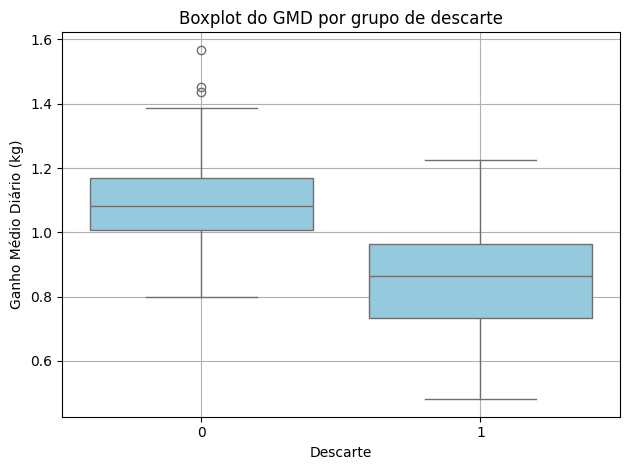

In [ ]:
#===============================================================================
#               BoxPlot
#===============================================================================

# Merge coluna Descarte do df para estatisticas

estatisticas = estatisticas.merge(df[['AnimalID', 'Descarte']].drop_duplicates(), on='AnimalID', how='left')

sns.boxplot(x='Descarte', y='GMD_medio', data=estatisticas, color='skyblue')
plt.title('Boxplot do GMD por grupo de descarte')
plt.ylabel('Ganho Médio Diário (kg)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
#===============================================================================
#           Estatísticas
#===============================================================================

# Separar os grupos
grupo_descartados = df[df['Descarte'] == 'Sim']['GMD_medio'].dropna()
grupo_nao_descartados = df[df['Descarte'] == 'Não']['GMD_medio'].dropna()

# Estatísticas descritivas
media_descartado = grupo_descartados.mean()
dp_descartado = grupo_descartados.std()
media_nao_descartado = grupo_nao_descartados.mean()
dp_nao_descartado = grupo_nao_descartados.std()

print(f"Média GPD - Descartado: {media_descartado:.2f} kg")
print(f"Desvio Padrão GPD - Descartado: {dp_descartado:.2f} kg")
print(f"Média GPD - Não Descartado: {media_nao_descartado:.2f} kg")
print(f"Desvio Padrão GPD - Não Descartado: {dp_nao_descartado:.2f} kg")

Média GPD - Descartado: nan kg
Desvio Padrão GPD - Descartado: nan kg
Média GPD - Não Descartado: nan kg
Desvio Padrão GPD - Não Descartado: nan kg


In [ ]:
#===============================================================================
#                 Teste t de Student
#===============================================================================

# Definir os grupos
grupo_descartados = df[df['Descarte'] == 1]['GMD_medio']
grupo_nao_descartados = df[df['Descarte'] == 0]['GMD_medio']

# Executar o teste t
t_stat, p_valor = stats.ttest_ind(grupo_descartados, grupo_nao_descartados, equal_var=False)

# Exibir resultados
print(f"Estatística t: {t_stat:.2f}")
print(f"p-valor: {p_valor:.2e}")

# Interpretar
if p_valor < 0.05:
    print("Diferença estatisticamente significativa.")
else:
    print("Diferença NÃO significativa.")


Estatística t: -11.02
p-valor: 3.78e-22
Diferença estatisticamente significativa.


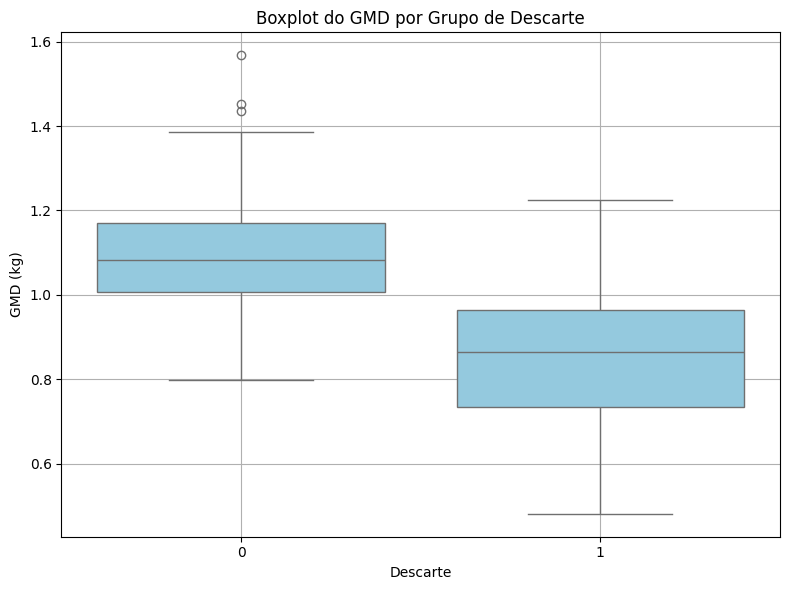

In [ ]:
#===============================================================================
#             Boxplot comparativo
#===============================================================================

plt.figure(figsize=(8, 6))
sns.boxplot(data=df[df['GMD_medio'].notna()], x='Descarte', y='GMD_medio', color='skyblue')
plt.title('Boxplot do GMD por Grupo de Descarte')
plt.ylabel('GMD (kg)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
#===============================================================================
#         Lista dos animais com o menor no z-score de GMD
#===============================================================================

# Ordenar pelo menor z-score (piores desempenhos relativos na variável GMD)
estatisticas_sorted = df.sort_values('z_score').reset_index(drop=True)

# Selecionar os 20 piores z-scores
animais_outliers_top20 = estatisticas_sorted[['AnimalID', 'GMD_medio', 'CustoTotal', 'z_score']].head(20)

# Exibir
print(animais_outliers_top20)

    AnimalID  GMD_medio  CustoTotal   z_score
0        172   0.481035  277.800905 -2.586797
1         77   0.500737  272.443697 -2.484886
2         72   0.528266  292.005184 -2.342482
3         83   0.553753  308.554902 -2.210643
4         23   0.594055  327.056527 -2.002173
5         50   0.611912  353.219517 -1.909798
6         27   0.624354  410.650852 -1.845443
7         89   0.639454  353.908115 -1.767330
8         64   0.645521  350.062265 -1.735948
9         67   0.649273  350.679577 -1.716542
10        61   0.651706  351.145638 -1.703957
11       134   0.653150  383.606097 -1.696484
12        33   0.667127  371.206872 -1.624184
13       167   0.676878  372.366457 -1.573746
14       120   0.679674  415.126748 -1.559285
15        63   0.679834  378.179481 -1.558457
16        75   0.680615  399.293285 -1.554413
17        51   0.693482  374.586844 -1.487855
18       185   0.695574  416.515229 -1.477034
19        76   0.705656  414.356637 -1.424884


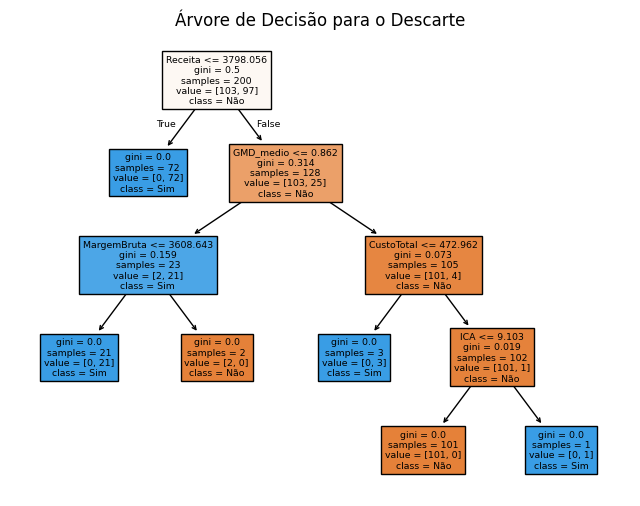

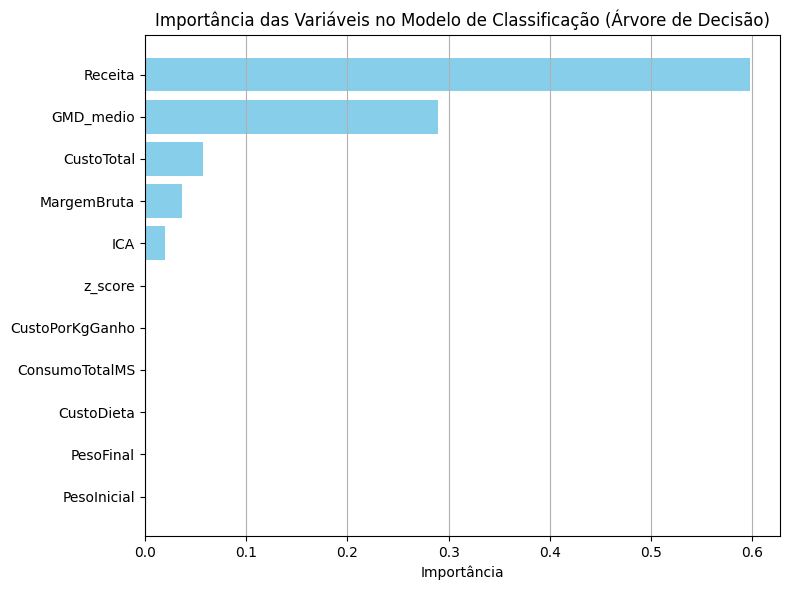

In [ ]:
#===============================================================================
#             Importância das variáveis
#===============================================================================

# Selecione features (X) and target (y)
# Exclui 'AnimalID' e 'Descarte' de features, and inclui colunas numéricas relevantes

X = df[variaveis_de_interesse]
y = df['Descarte']


# Initialize e treine uma Arvore de Decisão
modelo_dt = DecisionTreeClassifier(random_state=42)
modelo_dt.fit(X, y)


plt.figure(figsize=(8, 6))
plot_tree(modelo_dt, feature_names=X.columns, class_names=['Não', 'Sim'], filled=True)
plt.title("Árvore de Decisão para o Descarte")
plt.show()

# Pega as features importantes
importances = modelo_dt.feature_importances_
features = X.columns

# Ordenar por importância
sorted_idx = np.argsort(importances)

plt.figure(figsize=(8, 6))
plt.barh(features[sorted_idx], importances[sorted_idx], color='skyblue')
plt.xlabel('Importância')
plt.title('Importância das Variáveis no Modelo de Classificação (Árvore de Decisão)')
plt.grid(axis='x')
plt.tight_layout()
plt.show()

In [ ]:
#============================================================================================
#                   ??????
#============================================================================================

# Criar dataframe com AnimalID e Dieta (sem duplicações)
dieta_info = df[['AnimalID', 'Dieta']].drop_duplicates()

# Merge com o dataframe estatísticas
estatisticas = estatisticas.merge(dieta_info, on='AnimalID')

In [ ]:
from scipy.stats import levene

# Recalcula estatisticas do df original
estatisticas = df.groupby('AnimalID')['GMD_medio'].agg(['mean']).rename(columns={'mean': 'GMD_medio'})
estatisticas['z_score'] = (estatisticas['GMD_medio'] - estatisticas['GMD_medio'].mean()) / estatisticas['GMD_medio'].std(ddof=0)

# Cria um dataframe com relacão AnimalID x Dieta
dieta_info = df[['AnimalID', 'Dieta']].drop_duplicates()

# Merge com dataframe estatisticas e atualiza estatisticas
estatisticas = estatisticas.merge(dieta_info, on='AnimalID')

grupos = [estatisticas[estatisticas['Dieta'] == d]['GMD_medio'] for d in estatisticas['Dieta'].unique()]
stat, p = levene(*grupos)
print(f'Levene: stat={stat:.3f}, p={p:.4f}')

Levene: stat=0.823, p=0.4408


In [ ]:
#===============================================================================
#     ????
#===============================================================================

from statsmodels.formula.api import ols
import statsmodels.api as sm

modelo = ols('GMD_medio ~ C(Dieta)', data=estatisticas).fit()
anova = sm.stats.anova_lm(modelo, typ=2)

print(anova)


            sum_sq     df         F        PR(>F)
C(Dieta)  3.287223    2.0  78.02383  1.104942e-25
Residual  4.149904  197.0       NaN           NaN


In [ ]:
#===============================================================================
#       ??????
#===============================================================================


from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(
    endog=estatisticas['GMD_medio'],
    groups=estatisticas['Dieta'],
    alpha=0.05
)

print(tukey)


Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
     A      B  -0.1945   0.0 -0.2553 -0.1336   True
     A      C   0.1189   0.0  0.0606  0.1771   True
     B      C   0.3133   0.0  0.2539  0.3728   True
---------------------------------------------------


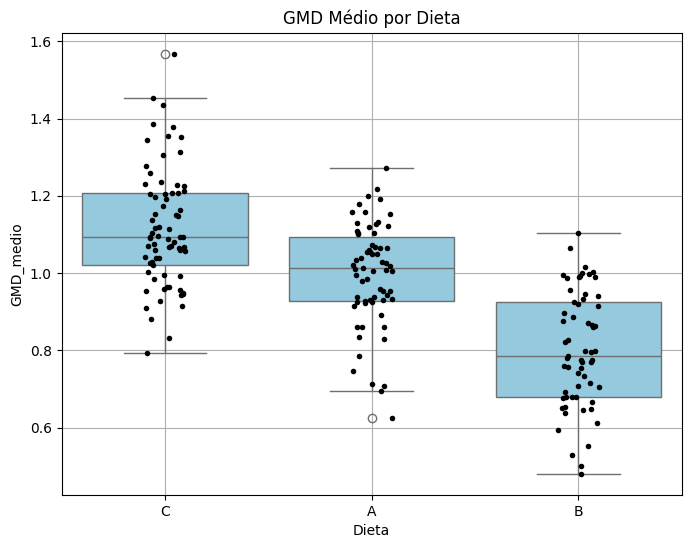

In [ ]:
#===============================================================================
#             ?????
#===============================================================================

plt.figure(figsize=(8, 6))
sns.boxplot(data=estatisticas, x='Dieta', y='GMD_medio',color = 'skyblue')
sns.stripplot(data=estatisticas, x='Dieta', y='GMD_medio', color='black', size=4, jitter=True)

plt.title('GMD Médio por Dieta')
plt.grid(True)
plt.show()


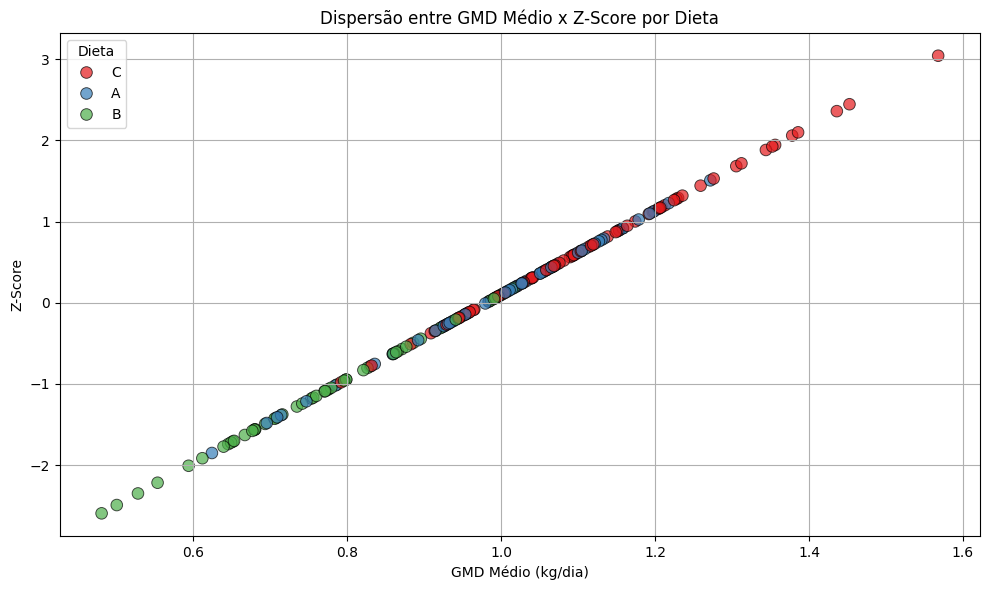

In [ ]:
#===============================================================================
#             Gráfico de Dispersão de que????
#===============================================================================

# Create a dataframe with the relation AnimalID - Dieta
dieta_info = df[['AnimalID', 'Dieta']].drop_duplicates().reset_index(drop=True)

# Ensure 'estatisticas' has 'AnimalID' as a column
if 'AnimalID' not in estatisticas.columns:
    estatisticas = estatisticas.reset_index()

# Select relevant columns from estatisticas and merge with dieta_info
# Explicitly select columns from estatisticas to avoid potential issues
estatisticas_for_merge = estatisticas[['AnimalID', 'GMD_medio', 'z_score']].copy()

# Merge estatisticas with dieta_info
estatisticas_merged = estatisticas_for_merge.merge(dieta_info, on='AnimalID')

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=estatisticas_merged,
    x='GMD_medio',
    y='z_score',
    hue='Dieta',
    palette='Set1',   # Você pode trocar por 'Set2', 'Set3', 'Dark', etc.
    s=70,
    alpha=0.7,
    edgecolor='black'
)

plt.title('Dispersão entre GMD Médio x Z-Score por Dieta')
plt.xlabel('GMD Médio (kg/dia)')
plt.ylabel('Z-Score')
plt.grid(True)
plt.tight_layout()
plt.show()

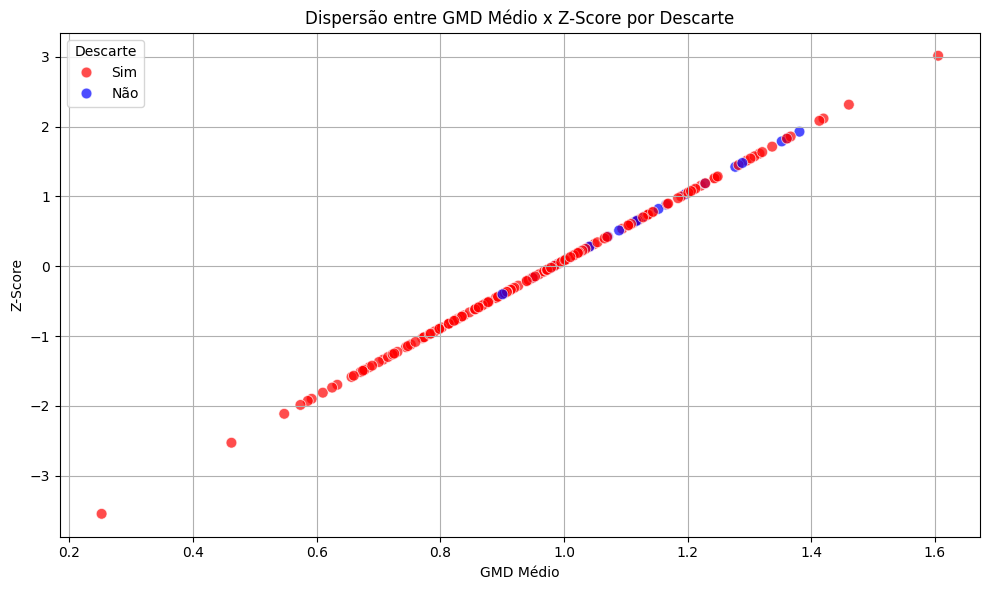

In [ ]:
#===============================================================================
#           Grafico de disperção de que?
#===============================================================================

# Simular dados
np.random.seed(42)
num_animais = 200
dias = 30
animais = np.arange(1, num_animais + 1)
dietas = np.random.choice(['A', 'B', 'C'], size=num_animais)
peso_inicial = np.random.uniform(300, 360, size=num_animais)
ganho_base = {'A': 1.0, 'B': 0.8, 'C': 1.1}
ganho_medio_animal = []

for i in range(num_animais):
    base = ganho_base[dietas[i]]
    gmd = np.random.normal(base, 0.15)
    gmd = max(gmd, 0)
    ganho_medio_animal.append(gmd)

registros = []
for idx, animal in enumerate(animais):
    peso = peso_inicial[idx]
    for dia in range(1, dias + 1):
        if dia > 1:
            ganho_dia = np.random.normal(ganho_medio_animal[idx], 0.2)
            ganho_dia = max(ganho_dia, -0.3)
            peso += ganho_dia
        registros.append([animal, dia, peso])

dr = pd.DataFrame(registros, columns=['AnimalID', 'Dia', 'Peso'])
dr['Ganho_diario'] = dr.groupby('AnimalID')['Peso'].diff()

peso_final = dr.groupby('AnimalID')['Peso'].last()
peso_ini = dr.groupby('AnimalID')['Peso'].first()
GMD = (peso_final - peso_ini) / (dias - 1)
estatisticas = dr.groupby('AnimalID')['Ganho_diario'].agg(['mean', 'std']).rename(columns={'mean': 'GMD_medio', 'std': 'DP_ganho'})

media_pop = estatisticas['GMD_medio'].mean()
dp_pop = estatisticas['GMD_medio'].std(ddof=0)
estatisticas['z_score'] = (estatisticas['GMD_medio'] - media_pop) / dp_pop

criterio_descarte = (peso_final < 380) | (GMD < 0.9)
estatisticas['Descarte'] = np.where(criterio_descarte, 'Sim', 'Não')

# Gráfico de dispersão
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=estatisticas,
    x='GMD_medio',
    y='z_score',
    hue='Descarte',
    palette={'Sim': 'red', 'Não': 'blue'},
    s=60,
    alpha=0.7
)
plt.title('Dispersão entre GMD Médio x Z-Score por Descarte')
plt.xlabel('GMD Médio')
plt.ylabel('Z-Score')
plt.grid(True)
plt.tight_layout()
plt.show()


# 7.2 Verificação das Suposições (Análise dos Resídios)

In [ ]:
da = df

Estatística t: -4.761
Valor p: 0.000031
Diferença estatisticamente significativa ao nível de 5%


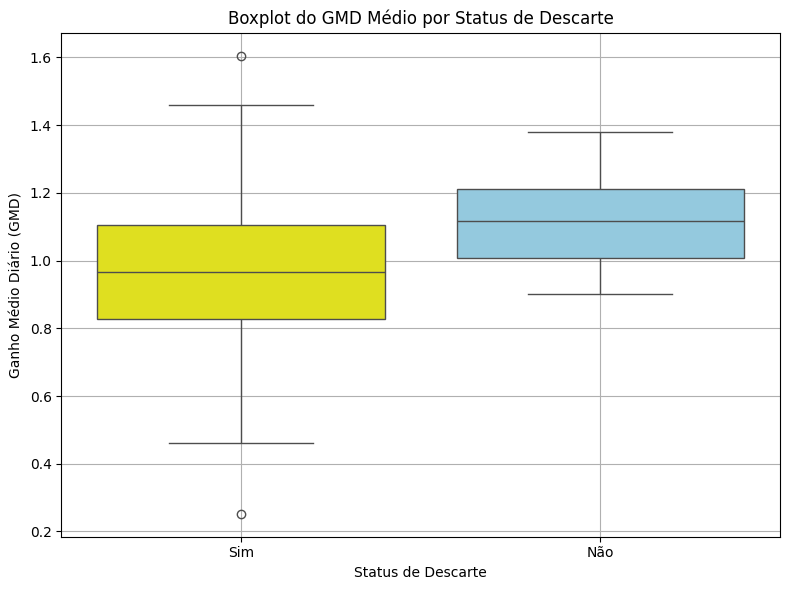

In [ ]:
#===============================================================================
#             Test T ?????
#===============================================================================

# Simular dados
np.random.seed(42)
num_animais = 200
dias = 30

dietas = np.random.choice(['A', 'B', 'C'], size=num_animais)
peso_inicial = np.random.uniform(300, 360, size=num_animais)
ganho_base = {'A': 1.0, 'B': 0.8, 'C': 1.1}
ganho_medio_animal = []

for i in range(num_animais):
    base = ganho_base[dietas[i]]
    gmd = np.random.normal(base, 0.15)
    gmd = max(gmd, 0)
    ganho_medio_animal.append(gmd)

registros = []
for idx in range(num_animais):
    peso = peso_inicial[idx]
    for dia in range(1, dias + 1):
        if dia > 1:
            ganho_dia = np.random.normal(ganho_medio_animal[idx], 0.2)
            ganho_dia = max(ganho_dia, -0.3)
            peso += ganho_dia
        registros.append([idx + 1, dia, peso])

df = pd.DataFrame(registros, columns=['AnimalID', 'Dia', 'Peso'])
df['Ganho_diario'] = df.groupby('AnimalID')['Peso'].diff()

peso_final = df.groupby('AnimalID')['Peso'].last()
peso_ini = df.groupby('AnimalID')['Peso'].first()
GMD = (peso_final - peso_ini) / (dias - 1)

estatisticas = df.groupby('AnimalID')['Ganho_diario'].agg(['mean', 'std']).rename(columns={'mean': 'GMD_medio', 'std': 'DP_ganho'})

# Add diet information to estatisticas
diet_df = pd.DataFrame({'AnimalID': range(1, num_animais + 1), 'Dieta': dietas})
estatisticas = estatisticas.merge(diet_df, on='AnimalID')


# Calcular z-score
media_pop = estatisticas['GMD_medio'].mean()
dp_pop = estatisticas['GMD_medio'].std(ddof=0)
estatisticas['z_score'] = (estatisticas['GMD_medio'] - media_pop) / dp_pop

# Definir critério de descarte
criterio_descarte = (peso_final < 380) | (GMD < 0.9)
estatisticas['Descarte'] = np.where(criterio_descarte, 'Sim', 'Não')

# Teste t de Student
grupo_sim = estatisticas[estatisticas['Descarte'] == 'Sim']['GMD_medio']
grupo_nao = estatisticas[estatisticas['Descarte'] == 'Não']['GMD_medio']
t_stat, p_valor = ttest_ind(grupo_sim, grupo_nao, equal_var=False)

print(f'Estatística t: {t_stat:.3f}')
print(f'Valor p: {p_valor:.6f}')
if p_valor < 0.05:
    print("Diferença estatisticamente significativa ao nível de 5%")
else:
    print("Diferença NÃO significativa ao nível de 5%")

# Gráfico boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=estatisticas,
    x='Descarte',
    y='GMD_medio',
    hue='Descarte',
    legend=False,
    palette={'Sim': 'yellow', 'Não': 'skyblue'}
)

plt.title('Boxplot do GMD Médio por Status de Descarte')
plt.xlabel('Status de Descarte')
plt.ylabel('Ganho Médio Diário (GMD)')
plt.grid(True)
plt.tight_layout()
plt.show()

Se p < 0.05: existe diferença significativa no GMD médio entre os animais descartados e os não descartados.

Esse teste ajuda a validar que o critério de descarte está relacionado com desempenho real

In [ ]:
df = da

In [ ]:
# Testes de normalidade

from scipy.stats import shapiro, normaltest

# Shapiro-Wilk
stat_shapiro, p_shapiro = shapiro(estatisticas['GMD_medio'])
print("Teste de Shapiro-Wilk:")
print(f"Estatística: {stat_shapiro:.4f}, p-valor: {p_shapiro:.6f}")
if p_shapiro < 0.05:
    print("Rejeita normalidade (nível 5%)")
else:
    print("Não rejeita normalidade")

print()

# D'Agostino-Pearson
stat_dagostino, p_dagostino = normaltest(estatisticas['GMD_medio'])
print("Teste de D'Agostino-Pearson:")
print(f"Estatística: {stat_dagostino:.4f}, p-valor: {p_dagostino:.6f}")
if p_dagostino < 0.05:
    print("Rejeita normalidade (nível 5%)")
else:
    print("Não rejeita normalidade")

Teste de Shapiro-Wilk:
Estatística: 0.9966, p-valor: 0.939689
Não rejeita normalidade

Teste de D'Agostino-Pearson:
Estatística: 1.4353, p-valor: 0.487891
Não rejeita normalidade


In [ ]:
# Analise de variancia entre as dietas A, B e C

# Aplicar o teste de Tukey
tukey = pairwise_tukeyhsd(endog=estatisticas['GMD_medio'], groups=estatisticas['Dieta'], alpha=0.05)

# Mostrar resultados
print(tukey)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     A      B  -0.1872    0.0 -0.2563 -0.118   True
     A      C   0.1199 0.0001  0.0537  0.186   True
     B      C    0.307    0.0  0.2395 0.3746   True
---------------------------------------------------


# 8. Interpretações dos Resultados

In [ ]:
# Filtrar animais que foram descartados
animais_descartados = estatisticas[estatisticas['Descarte'] == 'Sim'].copy()

# Resetar índice e selecionar colunas relevantes
animais_descartados = animais_descartados.reset_index()
animais_descartados = animais_descartados[['AnimalID', 'GMD_medio', 'DP_ganho', 'z_score', 'Descarte']]

# Exibir a tabela
print(animais_descartados)

descartes = df[df['Descarte'] == 'Sim']
print("Animais descartados:", animais_descartados.shape[0])

     AnimalID  GMD_medio  DP_ganho   z_score Descarte
0           1   1.243013  0.209621  1.258244      Sim
1           2   1.112702  0.235725  0.626535      Sim
2           3   1.049139  0.218576  0.318403      Sim
3           4   0.838297  0.211062 -0.703693      Sim
4           5   0.948179  0.258785 -0.171019      Sim
..        ...        ...       ...       ...      ...
172       196   0.979039  0.218472 -0.021419      Sim
173       197   1.168440  0.238860  0.896735      Sim
174       198   0.877214  0.190346 -0.515032      Sim
175       199   0.861898  0.219772 -0.589281      Sim
176       200   0.689665  0.186985 -1.424211      Sim

[177 rows x 5 columns]
Animais descartados: 177


# 9. Conclusão

Este projeto foi desenvolvido com a intencao de criar um road map na utilizacao dos metodos estatisticos para a analise do dataframe de animais. Como eu nao encontrei um dataframe com as variaveis que descobrir na aplicacao de tecnologia nas fazendas de pecuaria para confinamento de bovinos de corte. O principal objetivo era descobrir que animais devem ser descartados da fazenda por nao atingir os criterios de negocios pre-estabelecidos

Sao muitas as variaveis entao eu procurei criar um dataset com aquela variaveis que de antemao eu achava tinha importancia no modelo de descarte, mas nao tinha uma indicacao tecnica daquelas que estatisticamente realmente eram importantes. Muitas outras variaveis foram deixadas de lado e que certamente deveriam ser consideradas, que certamente serao utilizadas em futuros trabalhos.

Antes de seguir o escopo segeridos pelos professores, eu gerei o dataset dos animais, que certamente nao reflete a situacao real de criacao de animais em confinamento, mas que certamente é de muita valia para os trabalhos dessa cadeira. Procurei utilizar o meu conhecimento ja adquirido nos trabalhos de automacao de fazendas que ja a alguns anos eu realizo

Com esse dataset criado, segui o escopo sugerido. Pesquisei bastante o universo de testes existententes e as metodologias a serem seguidas. Fiz muita pesquisa, refiz muita coisa, e sempre procurei explicar ao maximo o objetivo dos testes, e acima de tudo, os requisitos a serem verificados antes de cada teste. O mais complicado foi a interpretacao dos resultados dos testes. O meu desconhecimento dos teste certamente podem ter causado algumas interpretacoes equivocadas, mas essa interpretacao correta dos teste é o motivo para esta particiapando desta cadeira - aprender o uso dos testes, qual o objetivo delas e como absorver os retornos de cada um deles.

Vejo esse trabalho como um guia para trabalhar com estatisticas em projetos futuros, como a pratica aprenderemos. Nao tenho a pretencao de ser um projeto completo finalizado, mas o coloco a disposicao de quem assim o desejar, e todo retorno dos meus erros e enganos serão muito bem vindos.

**Não tenho medo de errar, tenho receio é de nāo tentar, e estejam certo que nāo existe idade para se aprender mais sobre o mundo. Toda hora é a hora certa, e só terminará quando partirmos para o infinito. E imaginar que há alguns meses eu não sabia nada disso!!**